# Análisis exploratorio de Datos
Carlos Romero, Sergio Rada, Camilo Gónzales

## Introducción

Desde su aparición a finales de 2019, la pandemia de COVID-19 generó un impacto significativo en los sistemas de salud a nivel mundial, evidenciando la necesidad de contar con herramientas que permitan analizar y anticipar el comportamiento de la enfermedad. En este contexto, el análisis de datos epidemiológicos se ha convertido en un elemento clave para comprender los factores asociados a la evolución clínica de los pacientes y apoyar la toma de decisiones en salud pública.

El presente proyecto se enfoca en el análisis exploratorio de datos (EDA) de un conjunto de registros de casos de COVID-19 reportados en el departamento del Atlántico, Colombia. Este conjunto de datos contiene información relevante sobre características demográficas, epidemiológicas y clínicas de los pacientes, tales como edad, sexo, tipo de contagio, ubicación del caso, estado del paciente y fechas relacionadas con el diagnóstico y evolución de la enfermedad.

## Objetivo

El objetivo principal del análisis es estudiar las variables presentes en el dataset y explorar sus patrones, distribuciones y posibles relaciones con el fin de identificar factores asociados a la severidad de los casos de COVID-19. En este proyecto, la severidad se entiende como el nivel de gravedad que alcanza la enfermedad en un paciente, pudiendo manifestarse desde casos leves que se manejan en casa hasta casos críticos que requieren hospitalización, ingreso a unidades de cuidados intensivos o que resultan en fallecimiento.

A partir de este análisis exploratorio se busca preparar y comprender adecuadamente los datos para el desarrollo posterior de modelos de Machine Learning capaces de predecir la severidad de los casos. Estos modelos permitirían identificar patrones que ayuden a estimar el riesgo de evolución grave de un paciente basándose en sus características demográficas y epidemiológicas.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import anderson, levene, chi2_contingency

In [2]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport

#Carga del dataset
filename = r"C:\Users\User\Desktop\MachineLearningUN\EDA_entregable1_ml\Casos_positivos_final.csv"
df = pd.read_csv(filename,sep=',')



C:\Users\User\AppData\Local\Temp\ipykernel_13668\3198091402.py:7: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename,sep=',')


# Características del Dataset

## Dimensiones 
Inicialmente es necesario observar las dimensiones del dataset para tener conocimiento sobre el número de entradas y de variables presentes:

In [3]:
#Dimensiones del dataset
df.shape

(419061, 23)

Este dataset cuenta con 419061 entradas, cada una representando a un caso positivo de COVID-19 en el departamento del Atlántico, y cada entrada es caracterizada por 23 variables que serán explicadas a continuación.

## Descripción de variables
Se observan las primeras 5 entradas para familiarizarse con la estructura de cada una, seguido de esto se describe cada variable con su tipo:

In [4]:
#Primeras 5 filas de datos
df.head().T

,0,1,2,3,4
fecha reporte web,2021-01-13 00:00:00,2020-07-18 00:00:00,2020-09-23 00:00:00,2020-07-18 00:00:00,2020-07-18 00:00:00
ID de caso,1.830.848,186.958,781.861,187.670,186.906
Fecha de notificación,2020-12-27 00:00:00,2020-06-30 00:00:00,2020-09-11 00:00:00,2020-07-01 00:00:00,2020-06-30 00:00:00
Código DIVIPOLA departamento,8.0,8.0,8.0,8.0,8.0
Nombre departamento,ATLANTICO,ATLANTICO,ATLANTICO,ATLANTICO,ATLANTICO
Código DIVIPOLA municipio,8.758,8.758,8.758,8.634,8.758
Nombre municipio,SOLEDAD,SOLEDAD,SOLEDAD,SABANAGRANDE,SOLEDAD
Edad,75,52,80,21,15
Unidad de medida de edad,1,1,1,1,1
Sexo,M,F,F,F,F


In [5]:
#Información básica del dataset y de cada variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419061 entries, 0 to 419060
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   fecha reporte web             419061 non-null  object 
 1   ID de caso                    419061 non-null  object 
 2   Fecha de notificación         419061 non-null  object 
 3   Código DIVIPOLA departamento  419061 non-null  float64
 4   Nombre departamento           419061 non-null  object 
 5   Código DIVIPOLA municipio     419061 non-null  float64
 6   Nombre municipio              419061 non-null  object 
 7   Edad                          419061 non-null  int64  
 8   Unidad de medida de edad      419061 non-null  int64  
 9   Sexo                          419061 non-null  object 
 10  Tipo de contagio              419061 non-null  object 
 11  Ubicación del caso            416179 non-null  object 
 12  Estado                        416179 non-nul

## Diccionario de variables
A continuación se realiza una descripción clara de las variables del conjunto de datos de casos de COVID-19 en el departamento del Atlántico (Colombia) usando la información que aparece en la documentación y dando contexto de qué representa cada variable.  

- **fecha reporte web	(serie temporal):** Corresponde a la fecha en la que el caso fue publicado en el sitio web oficial del sistema de vigilancia epidemiológica.

- **ID de caso (identificador númerico):** Identificador numérico único asignado a cada caso dentro de la base de datos.

- **Fecha de notificación (serie temporal):** Fecha en la que el caso fue notificado al sistema de vigilancia en salud pública SIVIGILA. Esta fecha marca el momento en que la institución de salud reporta oficialmente el caso.

- **Código DIVIPOLA departamento (identificador númerico):** Código numérico del departamento según la clasificación DIVIPOLA utilizada por el DANE.

- **Nombre departamento (Categórica):** Nombre del departamento donde se registró el caso. 

- **Código DIVIPOLA municipio (identificador númerico):** Código DIVIPOLA que identifica el municipio específico dentro del departamento donde se registró el caso.
    - 08001, Barranquilla
    - 08078, Baranoa
    - 08137, Campo de la Cruz
    - 08141, Candelaria
    - 08296, Galapa
    - 08372, Juan de Acosta
    - 08421, Luruaco
    - 08433, Malambo
    - 08436, Manatí
    - 08520, Palmar de Varela
    - 08549, Piojó
    - 08558, Polonuevo
    - 08560, Ponedera
    - 08573, Puerto Colombia
    - 08606, Repelón
    - 08634, Sabanagrande
    - 08638, Sabanalarga
    - 08675, Santa Lucía
    - 08685, Santo Tomás
    - 08758, Soledad
    - 08770, Suan
    - 08832, Tubará
    - 08849, Usiacurí

- **Nombre municipio (Categórica):** Nombre del municipio donde se reporta el caso. En el departamento del Atlántico algunos ejemplos incluyen Barranquilla, Soledad, Sabanalarga, Malambo, Galapa, Baranoa, Puerto Colombia, Santo Tomás, entre otros.

- **Edad (Númerica discreta):** Edad de la persona diagnosticada con COVID-19. 

- **Unidad de medida de edad (Categórica codificada como númerica):** Unidad en la que se mide la edad del paciente. Entre ellas se encuentran las siguientes:  
    - 1 = años  
    - 2 = meses  
    - 3 = días  
Se utiliza especialmente para registrar edades de recién nacidos o niños pequeños.  

- **Sexo (Categórica):** Sexo biológico del paciente reportado en el sistema. Se clasifica como masculino (M) o femenino(F).

- **Tipo de contagio (Categórica):** Indica la forma en que se originó el contagio del caso. Puede clasificarse como:  
    - **Importado:** Cuando la infección se adquiere en otro país.  
    - **Relacionado:** Cuando existe contacto con un caso confirmado.  
    - **En estudio:** Cuando aún no se ha determinado el origen del contagio.  
    - **Comunitario:** Cuando la transmisión ocurre dentro de la comunidad.  

- **Ubicación del caso (Categórica):** Describe la ubicación o estado clínico del paciente en el momento del reporte. Puede indicar si el paciente se encuentra en casa, hospital, UCI o si corresponde a un caso fallecido no relacionado directamente con COVID-19.

- **Estado (Categórica):**  Estado actual del caso en el sistema epidemiológico. Puede incluir categorías como activo, recuperado o fallecido.

- **Código ISO del país (Identificador Númerico):** Codigo ISO del país del caso. Toda la columna es NA porque se estudian los casos de Colombia.  

- **Nombre del país (Categórica):** Nombre del país donde se encuentra el caso. Toda la columna es NA porque se estudian los casos de Colombia.  

- **Recuperado (Categórica):** Indica si el paciente se encuentra recuperado, fallecido o sin información disponible. También puede aparecer vacío en casos que aún se consideran activos.

- **Fecha de inicio de síntomas (Serie temporal):** Fecha en la que el paciente comenzó a presentar los primeros síntomas asociados al COVID-19.

- **Fecha de muerte (Serie temporal):** Fecha en la que ocurrió el fallecimiento del paciente en caso de que el caso haya terminado en muerte, sino es NA.

- **Fecha de diagnóstico (Serie temporal):** Fecha en la que el caso fue confirmado mediante pruebas de laboratorio.

- **Fecha de recuperación (Serie temporal):** Fecha en la que el paciente fue registrado como recuperado dentro del sistema de vigilancia epidemiológica.

- **Tipo de recuperación (Categórica):** Indica el método mediante el cual se determinó la recuperación del paciente:  
    - **PCR:** Confirmación mediante prueba negativa.  
    - **Tiempo:** Recuperación determinada tras cumplir el periodo de aislamiento establecido.  

- **Pertenencia étnica (Categórica):** Código que identifica la pertenencia étnica de la persona según su autodefinición. Puede incluir categorías como indígena, ROM, raizal, palenquero, afrodescendiente u otros grupos.

- **Nombre del grupo (Categórica):** Nombre del grupo étnico específico al que pertenece el paciente según la clasificación registrada en el sistema.
    - **1** - Indígena 
    - **2** - ROM
    - **3** - Raizal
    - **4** - Palenquero
    - **5** - Negro
    - **6** - Otro

# Pre-Procesamiento

## Tratamiento de valores faltantes
Seguido de esto se comprueba la existencia de valores faltantes para cada variable:

In [6]:
#Valores Faltantes
missing = df.isna().sum().to_frame("NaN")
missing["Porcentaje"] = (missing["NaN"] / len(df)) * 100
missing

,NaN,Porcentaje
fecha reporte web,0,0.000000
ID de caso,0,0.000000
Fecha de notificación,0,0.000000
Código DIVIPOLA departamento,0,0.000000
Nombre departamento,0,0.000000
Código DIVIPOLA municipio,0,0.000000
Nombre municipio,0,0.000000
Edad,0,0.000000
Unidad de medida de edad,0,0.000000
Sexo,0,0.000000


Se procedera a eliminar las variables con altos porcentajes de valores NaN, se tomara un límite de 10% para los porcentajes de NaN, si se supera este límite se estudia la variable antes de decidir eliminarla:

- **Código ISO del país** y **Nombre del país** son identificadores de cada país, como se trabajan unicamente los datos de Colombia, no vale la pena mantenerla en el dataset, además ambas tienen un porcentaje de valores NaN superior al 99%. 

- **Nombre del grupo étnico** es una variable que indica el nombre del grupo, más del 90% de sus variables son NaN, debido a fallos en el diligenciamiento o a pocos miembros pertenecientes al grupo étnico, se puede resaltar que el nombre más frecuente de esta variable es Mokana, pero por su cantidad de valores NaN será eliminada.

- **Fecha de muerte** tiene más del 90% de valores NaN, esto puede deberse a que solo un porcentaje pequeño de casos positivos terminaron en el fallecimiento del paciente, por tanto no aporta información suficiente al paciente, es mejor descartarla. Pero esto se hará luego de la imputación.


In [7]:
#Creamos una copia del dataset donde eliminaremos las variables mencionadas
df_limpio = df.drop(columns = ["Código ISO del país", "Nombre del país",
                              "Nombre del grupo étnico"])

## Otras variables a eliminar
En esta sección se eliminarán otras variables debido a que no son de interés particular para el estudio a realizar:
-   **ID del caso** Funciona únicamente como un identificador para cada caso por lo que no proporciona información de valor para la variable objetivo.

-   **Código DIVIPOLA departamento** y **Nombre departamento** son innecesarias debido a que se está trabajando únicamente con casos en el departamento del Atlántico y su capital Barranquilla.

-   **Nombre Municipio** será eliminada porque ya se cuenta con un identificador para los municipios que viene siendo **Código DIVIPOLA municipio** que ya está codificado como númerico, se transformará a entero para facilitar su manipulación.

In [8]:
#Ajustamos el codigo divipola para hacerlo mas facil de manipular
def convertir_divipola(valor):
    if pd.isna(valor):
        return None
    return int(round(valor * 1000))

df_limpio["Código DIVIPOLA municipio"] = df["Código DIVIPOLA municipio"].apply(convertir_divipola)

#eliminamos las columnas mencionadas
df_limpio = df_limpio.drop(columns = ["ID de caso", "Código DIVIPOLA departamento",
                              "Nombre departamento", "Nombre municipio"])

df_limpio.head().T



,0,1,2,3,4
fecha reporte web,2021-01-13 00:00:00,2020-07-18 00:00:00,2020-09-23 00:00:00,2020-07-18 00:00:00,2020-07-18 00:00:00
Fecha de notificación,2020-12-27 00:00:00,2020-06-30 00:00:00,2020-09-11 00:00:00,2020-07-01 00:00:00,2020-06-30 00:00:00
Código DIVIPOLA municipio,8758,8758,8758,8634,8758
Edad,75,52,80,21,15
Unidad de medida de edad,1,1,1,1,1
Sexo,M,F,F,F,F
Tipo de contagio,Comunitaria,Comunitaria,Comunitaria,Comunitaria,Comunitaria
Ubicación del caso,Casa,Casa,Casa,Casa,Casa
Estado,Leve,Leve,Leve,Leve,Leve
Recuperado,Recuperado,Recuperado,Recuperado,Recuperado,Recuperado


## Imputación de datos NaN

### Verificación de etiquetas

Antes de realizar la imputación, verificaremos las etiquetas de las variables categóricas una a una para verificar que no hayan errores de imputación:

In [9]:
#Ubicación del caso
target_table = pd.crosstab(index = df_limpio['Ubicación del caso'], columns = 'count')
target_table

col_0,count
Ubicación del caso,
CASA,1
Casa,402582
Fallecido,10257
Hospital,35
Hospital UCI,3
casa,3301


La etiqueta "Casa" se encuentra repetida. Se procede a unir a una sola etiqueta.

In [10]:
def normalizar_categoria(valor):
    if pd.isna(valor):
        return valor
    return valor.strip().lower().capitalize()

df_limpio["Ubicación del caso"] = df_limpio["Ubicación del caso"].apply(normalizar_categoria)

target_table = pd.crosstab(index = df_limpio['Ubicación del caso'], columns = 'count')
target_table

col_0,count
Ubicación del caso,
Casa,405884
Fallecido,10257
Hospital,35
Hospital uci,3


In [11]:
#Sexo
target_table = pd.crosstab(index = df_limpio['Sexo'], columns = 'count')
target_table

col_0,count
Sexo,
F,222971
M,196090


No hay errores.

In [12]:
#Tipo de contagio
target_table = pd.crosstab(index = df_limpio['Tipo de contagio'], columns = 'count')
target_table

col_0,count
Tipo de contagio,
Comunitaria,288243
Importado,74
Relacionado,130744


No hay errores.

In [13]:
#Estado
target_table = pd.crosstab(index = df_limpio['Estado'], columns = 'count')
target_table

col_0,count
Estado,
Fallecido,10257
Grave,3
LEVE,1
Leve,400808
Moderado,35
leve,5075


Etiqueta leve repetida varias veces, se corregira:

In [14]:
def normalizar_categoria(valor):
    if pd.isna(valor):
        return valor
    return valor.strip().lower().capitalize()

df_limpio["Estado"] = df_limpio["Estado"].apply(normalizar_categoria)

target_table = pd.crosstab(index = df_limpio['Estado'], columns = 'count')
target_table

col_0,count
Estado,
Fallecido,10257
Grave,3
Leve,405884
Moderado,35


Corregido.

In [15]:
#Recuperado
target_table = pd.crosstab(index = df_limpio['Recuperado'], columns = 'count')
target_table

col_0,count
Recuperado,
Activo,62
Fallecido,10246
Recuperado,406314
fallecido,11


La etiqueta fallecido se repite.

In [16]:
def normalizar_categoria(valor):
    if pd.isna(valor):
        return valor
    return valor.strip().lower().capitalize()

df_limpio["Recuperado"] = df_limpio["Recuperado"].apply(normalizar_categoria)

target_table = pd.crosstab(index = df_limpio['Recuperado'], columns = 'count')
target_table

col_0,count
Recuperado,
Activo,62
Fallecido,10257
Recuperado,406314


Corregido.

In [17]:
#Tipo de recuperación
target_table = pd.crosstab(index = df_limpio['Tipo de recuperación'], columns = 'count')
target_table

col_0,count
Tipo de recuperación,
PCR,97669
TIEMPO,5
Tiempo,308640


La etiqueta tiempo se repite, hay que corregir.

In [18]:
def normalizar_categoria(valor):
    if pd.isna(valor):
        return valor
    return valor.strip().lower().capitalize()

df_limpio["Tipo de recuperación"] = df_limpio["Tipo de recuperación"].apply(normalizar_categoria)

target_table = pd.crosstab(index = df_limpio['Tipo de recuperación'], columns = 'count')
target_table

col_0,count
Tipo de recuperación,
Pcr,97669
Tiempo,308645


Corregido.

In [19]:
#Pertenencia étnica
target_table = pd.crosstab(index = df_limpio['Pertenencia étnica'], columns = 'count')
target_table

col_0,count
Pertenencia étnica,
1.0,6264
2.0,6
3.0,1
5.0,17009
6.0,395741



### Imputación

Una vez verificado todas las etiquetas, procedamos con la imputación de los valores NaN en las variables que correspondan. Antes de realizar esto es necesario entender el contexto del dataset para realizar las imputaciones pertinentes, teniendo en cuenta de que la fecha de muerte no siempre tiene relación directa con muerte de covid, ya que registra la muerte aun si fue por otra causa después de recuperarse.

Para este caso existen valores NaN relacionados con las muertes, para las variables 'Recuperado' y 'Estado' que tienen un valor para los fallecidos se uso la siguiente técnica, si existía fecha de recuperación, y alguno de los valores faltaba, se imputaba la moda respectiva. Si existia fecha de fallecimiento y no había fecha de recuperación sinigicaba que el paciente habia muerto de covid, por tanto si hacía falta un valor en este tipo de entrada, se reemplazaba con fallecido. Por último, si había fecha de recuperación y también fecha de muerte, se imputaba la moda en cualquier valor faltante, de esta manera se mantuvo la consistencia entre estas variables.

Para el caso de 'tipo de recuperación', ya que esta solo aplica para personas que se recuperaron, por tanto tras la anterior imputación y teniendo definidio el número de pacientes que no se recuperó, este número se le asigna el valor categórico de 'no aplica', luego si hay fecha de recuperación y había NaN, se imputaba la moda.

Para 'etnia perteneciente' se imputo la moda.

In [20]:
#Verificación de casos inconsistentes, es decir que presenten valores distintos
def verificar_inconsistencias_fallecido(df_limpio):

    inconsistencias = df_limpio[
        ((df_limpio["Estado"] == "Fallecido") & (df_limpio["Recuperado"] != "Fallecido")) |
        ((df_limpio["Recuperado"] == "Fallecido") & (df_limpio["Estado"] != "Fallecido"))
    ]

    print("Número de inconsistencias:", inconsistencias.shape[0])
    
    return inconsistencias
errores = verificar_inconsistencias_fallecido(df_limpio)
errores

Número de inconsistencias: 0


,fecha reporte web,Fecha de notificación,Código DIVIPOLA municipio,Edad,Unidad de medida de edad,Sexo,Tipo de contagio,Ubicación del caso,Estado,Recuperado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha de recuperación,Tipo de recuperación,Pertenencia étnica


In [21]:

# asegurar formato fecha
df_limpio["Fecha de muerte"] = pd.to_datetime(df_limpio["Fecha de muerte"], errors="coerce")
df_limpio["Fecha de recuperación"] = pd.to_datetime(df_limpio["Fecha de recuperación"], errors="coerce")


#1 casos recuperados
mask_rec = df_limpio["Fecha de recuperación"].notna()

df_limpio.loc[
    mask_rec & df_limpio["Recuperado"].isna(),
    "Recuperado"
] = "Recuperado"

df_limpio.loc[
    mask_rec & df_limpio["Estado"].isna(),
    "Estado"
] = "Leve"

df_limpio.loc[
    mask_rec & df_limpio["Ubicación del caso"].isna(),
    "Ubicación del caso"
] = "Casa"

#2 casos fallecidos
mask_fall = (
    df_limpio["Fecha de muerte"].notna() &
    df_limpio["Fecha de recuperación"].isna()
)

df_limpio.loc[
    mask_fall & df_limpio["Recuperado"].isna(),
    "Recuperado"
] = "Fallecido"

df_limpio.loc[
    mask_fall & df_limpio["Estado"].isna(),
    "Estado"
] = "Fallecido"

df_limpio.loc[
    mask_fall & df_limpio["Ubicación del caso"].isna(),
    "Ubicación del caso"
] = "Fallecido"


#3 muerte + recuperación
mask_muerte_rec = (
    df_limpio["Fecha de muerte"].notna() &
    df_limpio["Fecha de recuperación"].notna()
)

df_limpio.loc[
    mask_muerte_rec & df_limpio["Recuperado"].isna(),
    "Recuperado"
] = "Recuperado"

df_limpio.loc[
    mask_muerte_rec & df_limpio["Estado"].isna(),
    "Estado"
] = "Leve"

df_limpio.loc[
    mask_muerte_rec & df_limpio["Ubicación del caso"].isna(),
    "Ubicación del caso"
] = "Casa"


#Imputación de tipo de recuperacion

#1 fallecidos → No aplica
mask_fallecidos = df_limpio["Estado"] == "Fallecido"

df_limpio.loc[
    mask_fallecidos & df_limpio["Tipo de recuperación"].isna(),
    "Tipo de recuperación"
] = "No aplica"


#2 recuperados con NaN → imputar modo
mask_recuperados_nan = (
    (df_limpio["Estado"] != "Fallecido") &
    (df_limpio["Tipo de recuperación"].isna())
)

df_limpio.loc[
    mask_recuperados_nan,
    "Tipo de recuperación"
] = "Tiempo"

#Etnia perteneciente

# calcular la moda
moda = df_limpio["Pertenencia étnica"].mode()[0]

# imputar valores faltantes
df_limpio["Pertenencia étnica"].fillna(moda, inplace=True)

#Se borra fecha de muerte porque ya no es util
df_limpio = df_limpio.drop(columns = ["Fecha de muerte"])


C:\Users\User\AppData\Local\Temp\ipykernel_13668\3655672267.py:96: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_limpio["Pertenencia étnica"].fillna(moda, inplace=True)


El Dataset resultante tras el pre-procesamiento sería el siguiente:

In [22]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419061 entries, 0 to 419060
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   fecha reporte web            419061 non-null  object        
 1   Fecha de notificación        419061 non-null  object        
 2   Código DIVIPOLA municipio    419061 non-null  int64         
 3   Edad                         419061 non-null  int64         
 4   Unidad de medida de edad     419061 non-null  int64         
 5   Sexo                         419061 non-null  object        
 6   Tipo de contagio             419061 non-null  object        
 7   Ubicación del caso           419061 non-null  object        
 8   Estado                       419061 non-null  object        
 9   Recuperado                   419061 non-null  object        
 10  Fecha de inicio de síntomas  416145 non-null  object        
 11  Fecha de diagnóstico      

In [23]:
df_limpio.head().T

,0,1,2,3,4
fecha reporte web,2021-01-13 00:00:00,2020-07-18 00:00:00,2020-09-23 00:00:00,2020-07-18 00:00:00,2020-07-18 00:00:00
Fecha de notificación,2020-12-27 00:00:00,2020-06-30 00:00:00,2020-09-11 00:00:00,2020-07-01 00:00:00,2020-06-30 00:00:00
Código DIVIPOLA municipio,8758,8758,8758,8634,8758
Edad,75,52,80,21,15
Unidad de medida de edad,1,1,1,1,1
Sexo,M,F,F,F,F
Tipo de contagio,Comunitaria,Comunitaria,Comunitaria,Comunitaria,Comunitaria
Ubicación del caso,Casa,Casa,Casa,Casa,Casa
Estado,Leve,Leve,Leve,Leve,Leve
Recuperado,Recuperado,Recuperado,Recuperado,Recuperado,Recuperado


Para una mejor claridad de los datos, las variables que tienen fechas serán separadas en dos columnas diferentes, una con el año y otra con el día del año, por ejemplo para "fecha reporte web" se hace una con año de reporte y día del reporte.  

In [24]:
# Paso mis variables que tienen tiempo, a objetos de tipo tiempo de pandas.
df_limpio["fecha reporte web"]=pd.to_datetime(df["fecha reporte web"])
df_limpio["Fecha de diagnóstico"]=pd.to_datetime(df["Fecha de diagnóstico"])
df_limpio["Fecha de inicio de síntomas"]=pd.to_datetime(df["Fecha de inicio de síntomas"])
df_limpio["Fecha de notificación"]=pd.to_datetime(df["Fecha de notificación"])
df_limpio["Fecha de recuperación"]=pd.to_datetime(df["Fecha de recuperación"])
df_limpio.head().T


,0,1,2,3,4
fecha reporte web,2021-01-13 00:00:00,2020-07-18 00:00:00,2020-09-23 00:00:00,2020-07-18 00:00:00,2020-07-18 00:00:00
Fecha de notificación,2020-12-27 00:00:00,2020-06-30 00:00:00,2020-09-11 00:00:00,2020-07-01 00:00:00,2020-06-30 00:00:00
Código DIVIPOLA municipio,8758,8758,8758,8634,8758
Edad,75,52,80,21,15
Unidad de medida de edad,1,1,1,1,1
Sexo,M,F,F,F,F
Tipo de contagio,Comunitaria,Comunitaria,Comunitaria,Comunitaria,Comunitaria
Ubicación del caso,Casa,Casa,Casa,Casa,Casa
Estado,Leve,Leve,Leve,Leve,Leve
Recuperado,Recuperado,Recuperado,Recuperado,Recuperado,Recuperado


In [25]:
# se hace una copia del dataset para manejar mejor la copia
df_copy=df_limpio.copy()

#aqui se separa la variable de fecha del reporte web para trabajarla mejor.  
df_copy["año reporte"]=df_copy["fecha reporte web"].dt.year
df_copy["dia del reporte"] = df_copy["fecha reporte web"].dt.dayofyear
df_copy=df_copy.drop(columns=["fecha reporte web"])
columna=df_copy.pop("año reporte")
df_copy.insert(0, "año reporte", columna)
columna=df_copy.pop("dia del reporte")
df_copy.insert(1, "dia del reporte", columna)

# ahora con los demás  

df_copy["año notificación"]=df_copy["Fecha de notificación"].dt.year
df_copy["dia de notificación"] = df_copy["Fecha de notificación"].dt.dayofyear
df_copy=df_copy.drop(columns=["Fecha de notificación"])
columna=df_copy.pop("año notificación")
df_copy.insert(3, "año notificación", columna)
columna=df_copy.pop("dia de notificación")
df_copy.insert(4, "dia de notificación", columna)

df_copy["año inicio sintomas"]=df_copy["Fecha de inicio de síntomas"].dt.year
df_copy["dia de inicio sintomas"] = df_copy["Fecha de inicio de síntomas"].dt.dayofyear
df_copy=df_copy.drop(columns=["Fecha de inicio de síntomas"])
columna=df_copy.pop("año inicio sintomas")
df_copy.insert(13, "año inicio sintomas", columna)
columna=df_copy.pop("dia de inicio sintomas")
df_copy.insert(14, "dia de inicio sintomas", columna)

df_copy["año diagnostico"]=df_copy["Fecha de diagnóstico"].dt.year
df_copy["dia diagnostico"] = df_copy["Fecha de diagnóstico"].dt.dayofyear
df_copy=df_copy.drop(columns=["Fecha de diagnóstico"])
columna=df_copy.pop("año diagnostico")
df_copy.insert(17, "año diagnostico", columna)
columna=df_copy.pop("dia diagnostico")
df_copy.insert(18, "dia diagnostico", columna)

df_copy["año recuperación"]=df_copy["Fecha de recuperación"].dt.year
df_copy["dia recuperación"] = df_copy["Fecha de recuperación"].dt.dayofyear
df_copy=df_copy.drop(columns=["Fecha de recuperación"])
columna=df_copy.pop("año recuperación")
df_copy.insert(19, "año recuperación", columna)
columna=df_copy.pop("dia recuperación")
df_copy.insert(19, "dia recuperación", columna)

df_copy.head().T

,0,1,2,3,4
año reporte,2021,2020,2020,2020,2020
dia del reporte,13,200,267,200,200
Código DIVIPOLA municipio,8758,8758,8758,8634,8758
año notificación,2020,2020,2020,2020,2020
dia de notificación,362,182,255,183,182
Edad,75,52,80,21,15
Unidad de medida de edad,1,1,1,1,1
Sexo,M,F,F,F,F
Tipo de contagio,Comunitaria,Comunitaria,Comunitaria,Comunitaria,Comunitaria
Ubicación del caso,Casa,Casa,Casa,Casa,Casa


Nuestra variable de respuesta será ESTADO, correspondiente al estado del paciente 

In [26]:
df_copy[df_copy["Estado"]=="Fallecido"].T

,38,44,109,113,123,139,171,223,224,225,...,418488,418537,418539,418565,418685,418832,418929,418986,418996,419053
año reporte,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2021,2021,2021,2021,2021,2021,2021,2021,2021,2022
dia del reporte,200,200,213,222,234,143,143,144,144,144,...,294,294,294,294,293,253,261,261,261,18
Código DIVIPOLA municipio,8758,8433,8758,8758,8638,8758,8634,8758,8573,8758,...,8001,8001,8001,8001,8001,8001,8001,8001,8001,8001
año notificación,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2021,2021,2021,2021,2021,2021,2021,2021,2021,2022
dia de notificación,199,197,209,208,231,136,136,132,138,140,...,287,287,288,290,289,248,113,255,258,16
Edad,61,79,78,36,89,96,77,82,79,87,...,66,72,79,94,39,61,63,78,54,83
Unidad de medida de edad,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Sexo,F,F,M,F,M,M,F,F,M,M,...,F,M,M,M,F,M,M,F,M,F
Tipo de contagio,Comunitaria,Comunitaria,Comunitaria,Comunitaria,Comunitaria,Relacionado,Comunitaria,Comunitaria,Comunitaria,Comunitaria,...,Comunitaria,Relacionado,Comunitaria,Comunitaria,Comunitaria,Comunitaria,Comunitaria,Comunitaria,Comunitaria,Comunitaria
Ubicación del caso,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,...,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido,Fallecido


## Análisis Univariado

El análisis univariado permite examinar cada variable de manera individual con el fin de entender su distribución, frecuencia y comportamiento dentro del conjunto de datos. Esto permite identificar patrones generales, posibles valores atípicos y la composición de las categorías presentes en los datos.

In [27]:
#importaciones
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Edad

In [28]:
df_edad_años = df_limpio[df_limpio["Unidad de medida de edad"] == 1]
df_edad_meses = df_limpio[df_limpio["Unidad de medida de edad"] == 2]
df_edad_dias = df_limpio[df_limpio["Unidad de medida de edad"] == 3]

In [29]:
df_edad_años["Edad"].describe()

count    416949.000000
mean         40.447637
std          19.366260
min           1.000000
25%          26.000000
50%          38.000000
75%          54.000000
max         113.000000
Name: Edad, dtype: float64

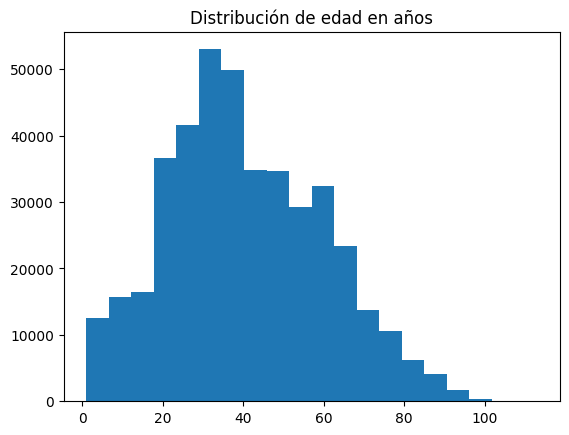

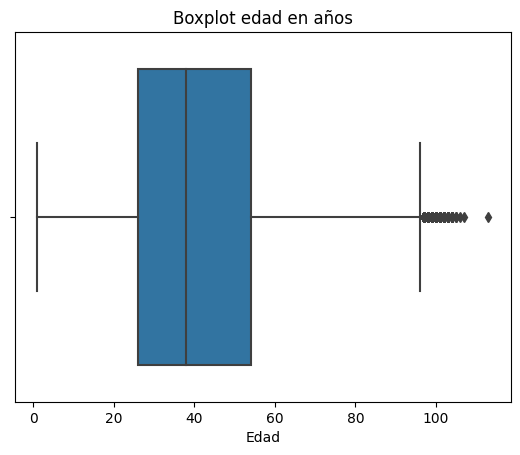

In [30]:
plt.hist(df_edad_años["Edad"], bins=20)
plt.title("Distribución de edad en años")
plt.show()
sns.boxplot(x=df_edad_años["Edad"])
plt.title("Boxplot edad en años")
plt.show()

In [31]:
df_edad_meses["Edad"].describe()

count    1917.000000
mean        5.579030
std         3.151306
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        18.000000
Name: Edad, dtype: float64

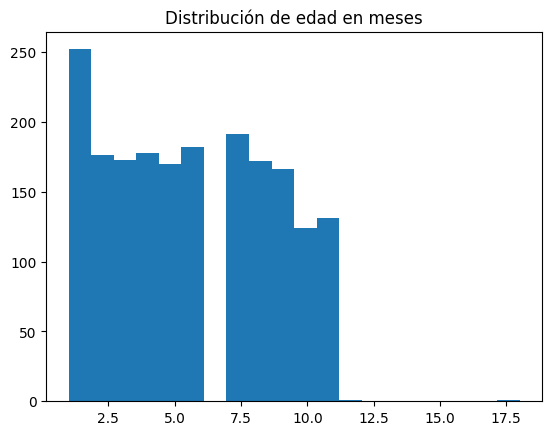

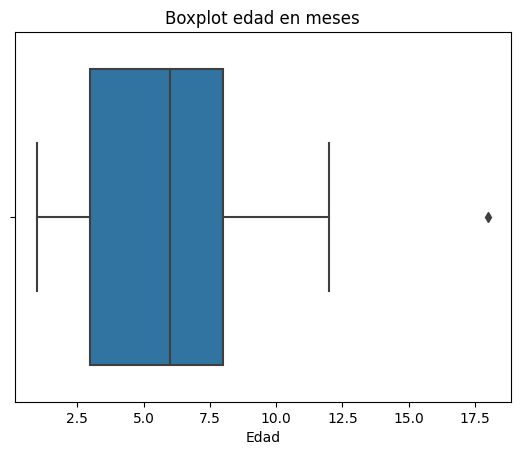

In [32]:
plt.hist(df_edad_meses["Edad"], bins=20)
plt.title("Distribución de edad en meses")
plt.show()
sns.boxplot(x=df_edad_meses["Edad"])
plt.title("Boxplot edad en meses")
plt.show()

In [33]:
df_edad_dias["Edad"].describe()

count    195.000000
mean      14.502564
std        8.822052
min        1.000000
25%        6.000000
50%       15.000000
75%       21.000000
max       30.000000
Name: Edad, dtype: float64

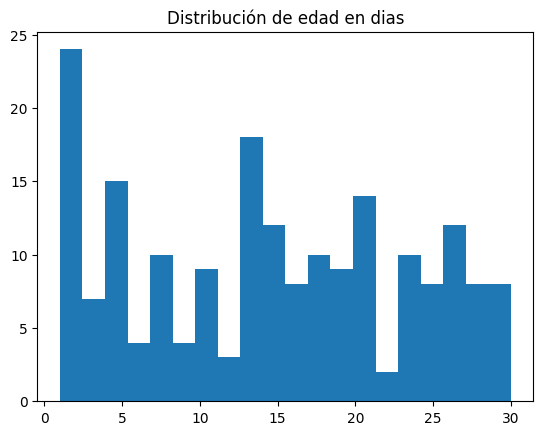

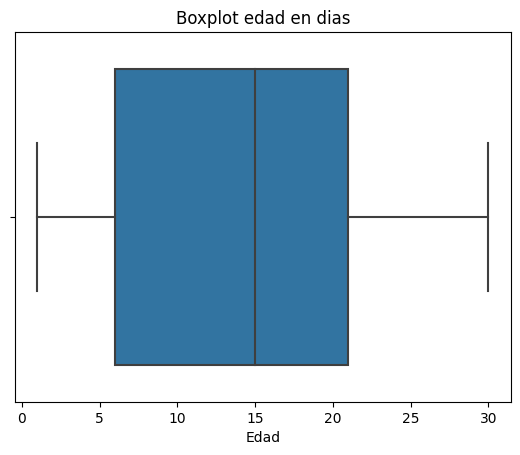

In [34]:
plt.hist(df_edad_dias["Edad"], bins=20)
plt.title("Distribución de edad en dias")
plt.show()
sns.boxplot(x=df_edad_dias["Edad"])
plt.title("Boxplot edad en dias")
plt.show()

#### Análisis Edad:

La variable **Edad** corresponde a una variable numérica que indica la edad de los individuos registrados en el conjunto de datos. Debido a que esta variable se encuentra expresada en diferentes unidades de medida (años, meses y días), el análisis se realiza por separado para cada una de estas categorías.

##### Edad en años
Para los registros donde la edad está expresada en años se cuentan **416,949 observaciones**. La edad promedio es aproximadamente **40.45 años**, con una desviación estándar de **19.37**, lo que muestra una variabilidad considerable entre las edades registradas. 

La edad mínima observada es **1 año**, mientras que la máxima alcanza los **113 años**. En cuanto a los cuartiles, el 25% de los individuos tiene **26 años o menos**, la mediana se encuentra en **38 años**, y el 75% tiene **54 años o menos**. Esto sugiere que la mayor parte de los casos se concentra en edades adultas.

##### Edad en meses
En los registros donde la edad está expresada en meses se tienen **1,917 observaciones**. La edad promedio es de aproximadamente **5.58 meses**, con una desviación estándar de **3.15 meses**.

El valor mínimo registrado es **1 mes** y el máximo **18 meses**. Los cuartiles muestran que el 25% de los individuos tiene **3 meses o menos**, la mediana es de **6 meses**, y el 75% tiene **8 meses o menos**, lo que indica que la mayoría de los registros corresponde a bebés menores de un año.

##### Edad en días
Para los casos en los que la edad está registrada en días se cuentan **195 observaciones**. La edad promedio es de aproximadamente **14.5 días**, con una desviación estándar de **8.82 días**.

El valor mínimo registrado es **1 día** y el máximo **30 días**. Los cuartiles indican que el 25% de los individuos tiene **6 días o menos**, la mediana es de **15 días**, y el 75% tiene **21 días o menos**, lo que refleja que estos registros corresponden principalmente a recién nacidos.

### Sexo

In [35]:
df_limpio["Sexo"].describe()

count     419061
unique         2
top            F
freq      222971
Name: Sexo, dtype: object

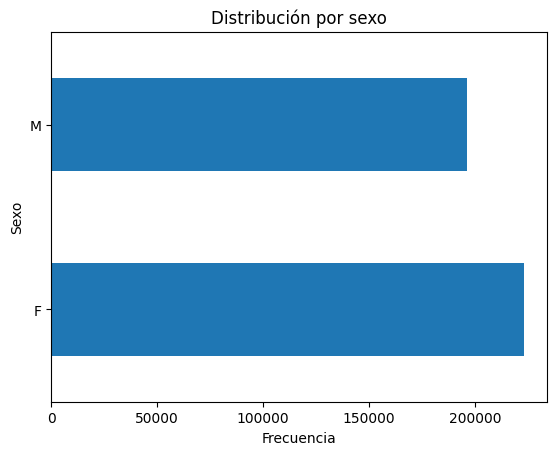

In [36]:
conteo = df_limpio["Sexo"].value_counts()

conteo.plot(kind="barh")

plt.title("Distribución por sexo")
plt.xlabel("Frecuencia")
plt.ylabel("Sexo")

plt.yticks(rotation=0)  # mantiene F y M derechos

plt.show()

#### Análisis Sexo:

La variable **Sexo** es una variable categórica que indica el sexo de los individuos registrados en el conjunto de datos.

En total se registran **419,061 observaciones** para esta variable, con **dos categorías únicas**. La categoría más frecuente es **F (femenino)** con **222,971 registros**, lo que representa la mayor proporción de los casos en el conjunto de datos.

Esto indica que, dentro de los datos analizados, la participación de individuos de sexo femenino es ligeramente mayor en comparación con el sexo masculino. La distribución observada puede apreciarse de forma más clara en el gráfico de barras presentado en el análisis exploratorio.

### Pertenencia Étnica

In [37]:
df_limpio["Pertenencia étnica"].describe()

count    419061.000000
mean          5.884609
std           0.633417
min           1.000000
25%           6.000000
50%           6.000000
75%           6.000000
max           6.000000
Name: Pertenencia étnica, dtype: float64

In [38]:
df_limpio["Pertenencia étnica"].value_counts(normalize=True) * 100

Pertenencia étnica
6.0    94.444723
5.0     4.058836
1.0     1.494770
2.0     0.001432
3.0     0.000239
Name: proportion, dtype: float64

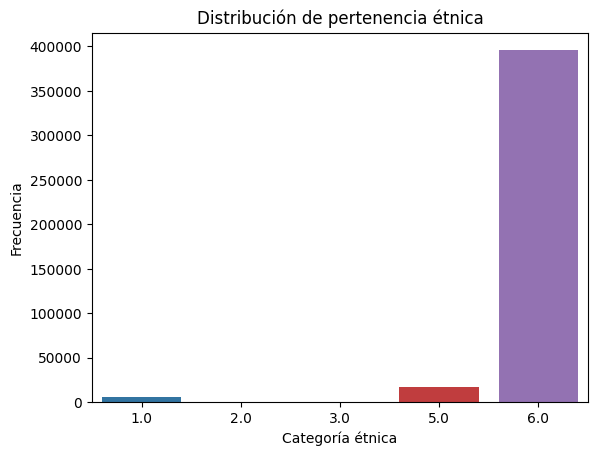

In [39]:
import seaborn as sns

sns.countplot(x="Pertenencia étnica", data=df_limpio)

plt.title("Distribución de pertenencia étnica")
plt.xlabel("Categoría étnica")
plt.ylabel("Frecuencia")

plt.show()

#### Análisis Pertenencia étnica:

La variable **Pertenencia étnica** es una variable categórica codificada numéricamente que identifica el grupo étnico al que pertenece cada individuo dentro del conjunto de datos.

A partir de los estadísticos descriptivos se observa que hay **419,061 registros** para esta variable. La media es aproximadamente **5.88** y la desviación estándar es **0.63**, lo que ya sugiere que la mayoría de los valores se concentran cerca de la categoría **6**. Además, los cuartiles (25%, 50% y 75%) también toman el valor **6**, lo que confirma que esta categoría domina claramente la distribución.

Al observar la distribución porcentual, se encuentra que la gran mayoría de los registros corresponde a la categoría **6**, con aproximadamente **94.44%** de los casos. En menor proporción aparece la categoría **5** con alrededor de **4.06%**, seguida por la categoría **1** con **1.49%**. Las categorías **2** y **3** aparecen con una frecuencia extremadamente baja dentro del conjunto de datos.

En general, la distribución muestra que casi todos los registros pertenecen a una misma categoría étnica, mientras que los demás grupos tienen una representación muy pequeña dentro del dataset analizado.

### Variables temporales

In [40]:
variables_tiempo = [
"año reporte",
"dia del reporte",
"año notificación",
"dia de notificación",
"año inicio sintomas",
"dia de inicio sintomas",
"año diagnostico",
"dia diagnostico",
"año recuperación",
"dia recuperación"
]

df_copy[variables_tiempo].describe()

,año reporte,dia del reporte,año notificación,dia de notificación,año inicio sintomas,dia de inicio sintomas,año diagnostico,dia diagnostico,año recuperación,dia recuperación
count,419061.000000,419061.000000,419061.000000,419061.000000,416145.000000,416145.000000,417917.000000,417917.000000,406317.000000,406317.000000
mean,2020.958973,143.091182,2020.931900,143.418383,2020.919490,146.097901,2020.948760,143.053810,2020.985041,145.502521
std,0.642944,94.447662,0.641054,98.312901,0.632757,101.022878,0.642948,96.406158,0.632480,94.258261
min,2020.000000,1.000000,2020.000000,1.000000,2020.000000,1.000000,2020.000000,1.000000,2020.000000,1.000000
25%,2021.000000,84.000000,2021.000000,80.000000,2021.000000,80.000000,2021.000000,84.000000,2021.000000,85.000000
50%,2021.000000,125.000000,2021.000000,123.000000,2021.000000,124.000000,2021.000000,123.000000,2021.000000,127.000000
75%,2021.000000,198.000000,2021.000000,192.000000,2021.000000,193.000000,2021.000000,195.000000,2021.000000,205.000000
max,2024.000000,366.000000,2024.000000,366.000000,2024.000000,366.000000,2024.000000,366.000000,2024.000000,366.000000


#### Análisis Variables temporales:

Las **variables temporales** del conjunto de datos describen los diferentes momentos del proceso de registro de un caso de COVID-19, como el reporte, la notificación, el inicio de síntomas, el diagnóstico y la recuperación. Estas variables permiten entender cómo se distribuyen los casos a lo largo del tiempo dentro del dataset.

En total se observan **419,061 registros** para las variables de **año y día de reporte y notificación**, mientras que algunas variables como **inicio de síntomas, diagnóstico y recuperación** tienen una cantidad ligeramente menor de registros debido a la presencia de algunos valores faltantes.

En cuanto al **año**, la mayoría de los registros se concentran en **2021**, ya que el valor de la mediana y de los cuartiles también corresponde a este año en casi todas las variables temporales. Sin embargo, el rango de los datos va aproximadamente desde **2020 hasta 2024**, lo que indica que el dataset incluye registros de varios años del seguimiento de la pandemia.

Respecto a los **días del año**, los valores van desde **1 hasta 366**, lo que representa el día específico dentro del año en que ocurrió cada evento (reporte, notificación, inicio de síntomas, diagnóstico o recuperación). La media de estos valores se encuentra alrededor de **143 a 146**, lo que sugiere que una gran parte de los casos registrados ocurrió aproximadamente hacia la mitad del año.

En general, estas variables temporales muestran que los eventos asociados a los casos (notificación, diagnóstico y recuperación) siguen una distribución similar en el tiempo, lo cual es consistente con el proceso epidemiológico en el que primero se presentan los síntomas, luego se realiza el diagnóstico y posteriormente se registra la recuperación.

### Variables acerca el estado

In [41]:
variables_estado = [
"Tipo de contagio",
"Ubicación del caso",
"Estado",
"Recuperado",
"Tipo de recuperación"
]

for v in variables_estado:
    print(df_copy[v].value_counts())

Tipo de contagio
Comunitaria    288243
Relacionado    130744
Importado          74
Name: count, dtype: int64
Ubicación del caso
Casa            406341
Fallecido        12682
Hospital            35
Hospital uci         3
Name: count, dtype: int64
Estado
Leve         406341
Fallecido     12682
Moderado         35
Grave             3
Name: count, dtype: int64
Recuperado
Recuperado    406317
Fallecido      12682
Activo            62
Name: count, dtype: int64
Tipo de recuperación
Tiempo       308710
Pcr           97669
No aplica     12682
Name: count, dtype: int64


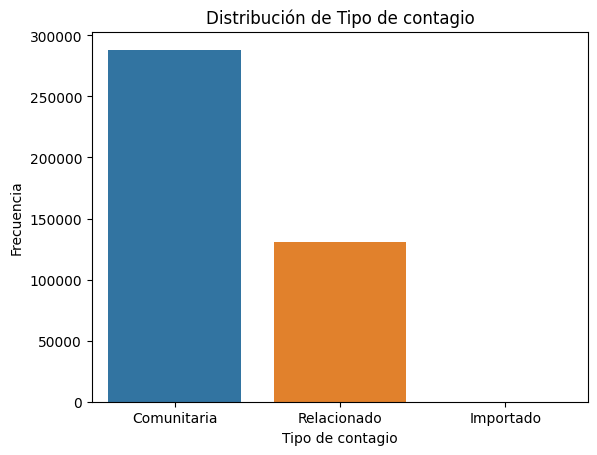

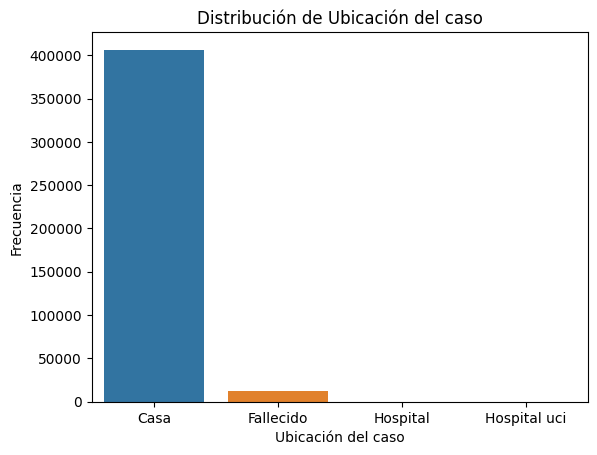

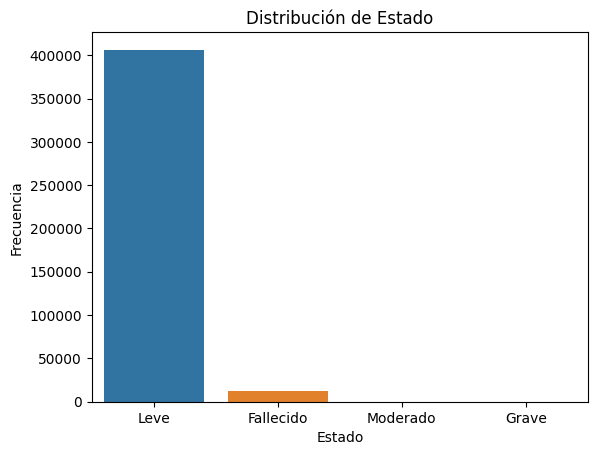

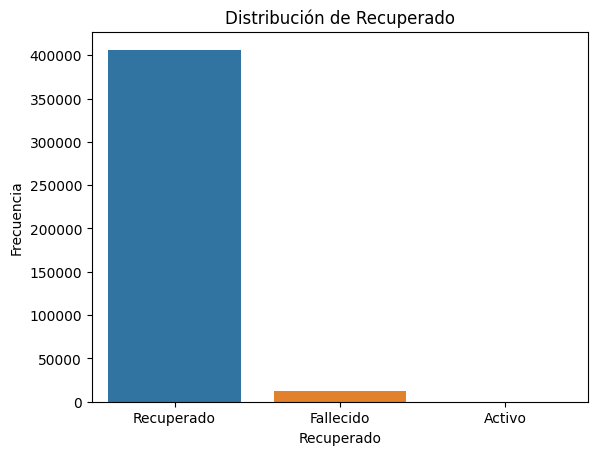

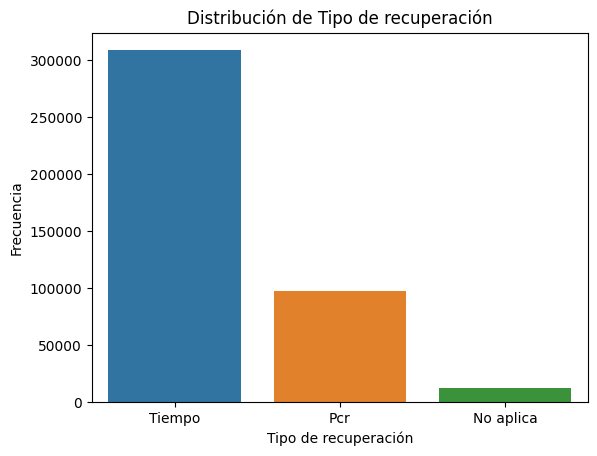

In [42]:
for v in variables_estado:
    plt.figure()
    sns.countplot(x=v, data=df_copy)
    
    plt.title(f"Distribución de {v}")
    plt.xlabel(v)
    plt.ylabel("Frecuencia")
    
    plt.show()

#### Análisis Variables relacionadas con el estado del caso:

Estas variables describen la **condición clínica del paciente, el tipo de contagio y el proceso de recuperación** de los casos registrados en el conjunto de datos.

En la variable **Tipo de contagio**, la mayoría de los casos corresponden a contagio **Comunitaria** con **288,243 registros**, seguido por **Relacionado** con **130,744 casos**. Los casos **Importados** son muy pocos, con solo **74 registros**, lo que indica que la gran mayoría de los contagios se dieron dentro de la misma comunidad.

Respecto a la **Ubicación del caso**, la mayor parte de los pacientes se encontraban en **Casa** con **406,341 registros**, lo que sugiere que la mayoría de los casos fueron manejados de forma ambulatoria. También aparecen **12,682 registros asociados a fallecidos**, mientras que los casos en **Hospital (35)** y **Hospital UCI (3)** representan una proporción muy pequeña dentro del dataset.

La variable **Estado** muestra un comportamiento muy similar. La mayoría de los casos son **Leves** con **406,341 registros**, mientras que **12,682 corresponden a fallecidos**. Los estados **Moderado (35)** y **Grave (3)** aparecen en muy poca proporción, lo cual coincide con la distribución observada en la ubicación del caso.

En cuanto a la variable **Recuperado**, se observa que **406,317 personas aparecen como recuperadas**, **12,682 fallecieron** y solo **62 casos permanecen activos** dentro del conjunto de datos.

Finalmente, en **Tipo de recuperación**, la mayoría de los casos se recuperaron **por tiempo** con **308,710 registros**, seguido de recuperación confirmada por **PCR** con **97,669 casos**. La categoría **No aplica (12,682)** corresponde principalmente a los casos que terminaron en fallecimiento.

En general, estas variables muestran que la mayoría de los casos registrados en el dataset fueron **leves, manejados en casa y terminaron en recuperación**, mientras que los casos graves, hospitalizados o importados representan una proporción muy pequeña del total de registros.

### Variable geográfica

In [43]:
df_limpio["Código DIVIPOLA municipio"].value_counts()

Código DIVIPOLA municipio
8001    277989
8758     67469
8638     12217
8433     10199
8078      8842
8573      8612
8296      7745
8685      4247
8520      3351
8634      3214
8558      2025
8372      1830
8137      1616
8560      1422
8832      1368
8436      1296
8849      1058
8606      1038
8421       971
8141       917
8770       752
8675       589
8549       294
Name: count, dtype: int64

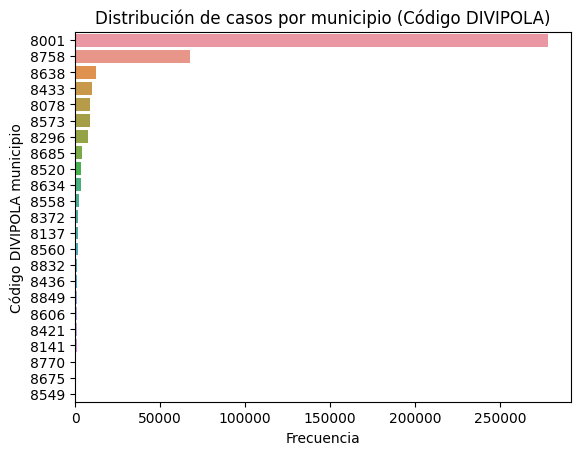

In [44]:
orden = df_copy["Código DIVIPOLA municipio"].value_counts().index

sns.countplot(y="Código DIVIPOLA municipio", data=df_copy, order=orden)

plt.title("Distribución de casos por municipio (Código DIVIPOLA)")
plt.xlabel("Frecuencia")
plt.ylabel("Código DIVIPOLA municipio")

plt.show()

#### Análisis Código DIVIPOLA municipio:

La variable **Código DIVIPOLA municipio** permite identificar el municipio del departamento del Atlántico donde fue registrado cada caso. Al observar la distribución de esta variable, se nota que los casos se encuentran repartidos entre varios municipios del departamento.

Dentro del conjunto de datos aparecen municipios como **Barranquilla (08001)**, **Soledad (08758)**, **Malambo (08433)**, **Sabanalarga (08638)**, **Puerto Colombia (08573)**, **Galapa (08296)**, **Baranoa (08078)**, **Santo Tomás (08685)**, **Sabanagrande (08634)**, **Palmar de Varela (08520)**, entre otros municipios del Atlántico.

En general, la distribución muestra que los registros se concentran principalmente en los municipios más poblados del departamento y en el área metropolitana de Barranquilla. Esto es coherente con lo esperado, ya que en estas zonas existe mayor densidad poblacional y movilidad de personas, lo que puede favorecer una mayor cantidad de casos reportados.

## Análisis Bivariado   

## Análisis de la variable de respuesta frente a las variables numéricas  

Se realizará la comparación de la variable "Estado" correspondiente al estado de salud del paciente con Covid-19 en dicha fecha. En este caso, la variable de respuesta tiene 4 categorias: Leve, Fallecito, Moderado y Grave;por tanto, se tomarán estos 4 grupos y se analizará frente a la unica variable numérica, "Edad", con un diagrama de cajas y bigotes, una tabla para comparación de la distribuciones y una prueba de igualdad de medidas de tendencia central.   
Veamos cómo es el comportamiento de Edad según el estado, diferenciando en la unidad de medida de edad 

In [45]:
# Unidad de medida de edad 1
df_adultos=df_limpio[(df_limpio["Unidad de medida de edad"]==1)]
df_adultos["Edad"].describe()

count    416949.000000
mean         40.447637
std          19.366260
min           1.000000
25%          26.000000
50%          38.000000
75%          54.000000
max         113.000000
Name: Edad, dtype: float64

In [46]:
# Unidad de medida de edad 2
df_bebe_meses=df_limpio[(df_limpio["Unidad de medida de edad"]==2)]
df_bebe_meses["Edad"].describe()

count    1917.000000
mean        5.579030
std         3.151306
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        18.000000
Name: Edad, dtype: float64

In [47]:
# unidad de medida de edad 3
df_bebe_dias=df_limpio[(df_limpio["Unidad de medida de edad"]==3)]
df_bebe_dias["Edad"].describe()

count    195.000000
mean      14.502564
std        8.822052
min        1.000000
25%        6.000000
50%       15.000000
75%       21.000000
max       30.000000
Name: Edad, dtype: float64

Con lo observado anteriormente, en esta sección se realizarán dos análisis porque en la variable se encuentran bebés donde su edad está expresada con un número pero depende de la variable "Unidad de medida de edad". Entonces se deben hacer un pequeño análisis con estos casos que no son más de 2112, correspondiende a bebés con edad menor a 18 meses, por tanto, los que son mayores de 18 meses se clasifican en el otro grupo y aparecen con edad de 1 año.  

### Gráfico de cajas y bigotes multiple para mayores de 18 meses

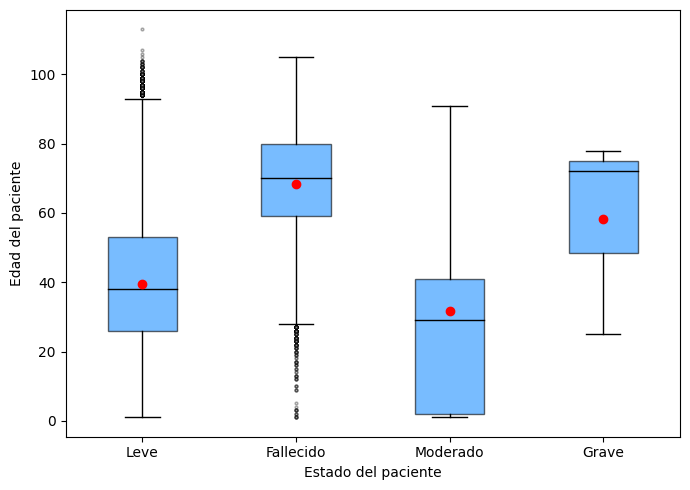

In [48]:
fig, ax = plt.subplots(figsize=(7, 5))

estados = df_adultos["Estado"].unique()

grupos = [
    df_adultos[df_adultos["Estado"] == g]["Edad"].dropna()
    for g in estados
]

bp = ax.boxplot(
    grupos,
    labels=estados,
    patch_artist=True,
    boxprops=dict(facecolor='#1E90FF', alpha=0.6, color='black'),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor='gray', marker='o', markersize=2, alpha=0.3)
)

for i, g in enumerate(grupos, start=1):
    ax.plot(i, g.mean(), marker='o', color='red', markersize=6, zorder=5)

ax.set_xlabel('Estado del paciente')
ax.set_ylabel('Edad del paciente')

plt.tight_layout()
plt.show()

**Descripción:**  
El gráfico muestra la distribución de la edad de los pacientes según el estado del individuo portador del covid-19 (Leve, fallecido, Moderado y Grave). Se observa una alta dispersión en todos los grupos, especialmente en los estados leve y fallecido, indicando que la edad por sí sola no determina el desenlace clínico. Además, los pacientes con mayor mediana de edad (entre 60 y 80 años) fueron los fallecidos y en estado grave,  esto sugiere que la edad avanzada es un factor de riesgo importante para desarrollar complicaciones graves o morir a causa del COVID-19; en cambio las personas con menor mediana de edad (por debajo de 40 años) fueron los que tuvieron en estado leve o moderado.  
Asimismo, se puede observar que en el grupo de personas con estado leve tiene valores atípicos, los cuales corresponden a personas mayores de 90 años que estuvieron en este estado, lo cual es atípico considerando que estos individuos son más propensos a fallecer; similarmente, en el grupo de fallecidos hubo datos atipicos que corresponden a personas menores de aproximadamente 30 años, lo cual es normal considerando que son más propensos a estar en estado leve, e inclusive salta a la vista casos de niños fallecidos que se pueden visualizar en la gráfica.  
De la misma manera, todos los grupos separados por el estado del paciente tienen distribuciones sesgadas, primeramente el grupo de estado leve tienen asimetría hacia la derecha y el grupo de fallecidos tienen asimetria hacia la izquierda. Cabe resaltar, que el grupo de Moderado y Grave no se le puede hacer mucho análisis descriptivo porque son muy pocos datos, 21 y 3 respectivamente, lo cual es poca la información de cómo es la distribución de estos grupos.    

### Comparación de medidas de tendencia central para mayores de 18 meses 

Gracias a lo anterior, se realizará el análisis de las medidas de tendencia central para la edad según el Estado del individuo.

In [49]:
def resumen(grupos):
    col = grupos["Edad"].dropna()
    return pd.Series({
        'n':          len(grupos['Edad']),
        'media':      col.mean(),
        'ds':         col.std(),
        'mediana':    col.median(),
        'minimo':     col.min(),
        'maximo':     col.max(),
        'Q1':         col.quantile(0.25),
        'Q3':         col.quantile(0.75),
        'IQR':        col.quantile(0.75) - col.quantile(0.25)
    })

tabla_grupos = df_adultos.groupby('Estado').apply(resumen).reset_index()

col_total = df_adultos['Edad'].dropna()
tabla_total = pd.DataFrame([{
    'Estado': 'TOTAL',
    'n':          len(df_adultos['Edad']),
    'media':      col_total.mean(),
    'ds':         col_total.std(),
    'mediana':    col_total.median(),
    'minimo':     col_total.min(),
    'maximo':     col_total.max(),
    'Q1':         col_total.quantile(0.25),
    'Q3':         col_total.quantile(0.75),
    'IQR':        col_total.quantile(0.75) - col_total.quantile(0.25)
}])
pd.concat([tabla_grupos, tabla_total], ignore_index=True).round(2)

C:\Users\User\AppData\Local\Temp\ipykernel_13668\3387086900.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_grupos = df_adultos.groupby('Estado').apply(resumen).reset_index()


,Estado,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,Fallecido,12660.0,68.35,15.87,70.0,1.0,105.0,59.0,80.0,21.0
1,Grave,3.0,58.33,29.02,72.0,25.0,78.0,48.5,75.0,26.5
2,Leve,404265.0,39.57,18.81,38.0,1.0,113.0,26.0,53.0,27.0
3,Moderado,21.0,31.81,28.90,29.0,1.0,91.0,2.0,41.0,39.0
4,TOTAL,416949.0,40.45,19.37,38.0,1.0,113.0,26.0,54.0,28.0


**Descripción**  
La tabla presenta estadísticas descriptivas de la edad de los pacientes según su estado clínico frente al COVID-19. En total se analizaron 416,949 pacientes, con una edad promedio de 40.45 años y una mediana de 38 años, observándose edades entre 1 y 113 años. La mayoría de los casos corresponde a pacientes con estado leve (404265), quienes presentan una media de edad de 39.57 años y una mediana de 38 años, lo que indica que los casos menos graves se concentran principalmente en personas jóvenes y de mediana edad.

En contraste, los pacientes fallecidos (12660) presentan una edad media considerablemente mayor (68.35 años) y una mediana de 70 años, lo que evidencia una mayor concentración de muertes en adultos mayores. Los estados moderado (21 casos) y grave (3 casos) muestran medias de edad de 31.81 y 58.33 años, respectivamente; sin embargo, estos grupos tienen tamaños de muestra muy pequeños, por lo que sus resultados deben interpretarse con cautela. En general, los datos sugieren que la edad más avanzada está asociada con desenlaces más graves o fatales en pacientes con COVID-19, lo cual, reafirma lo dicho en el gráfico.  

### Pruebas de normalidad de ambos grupos (mayores de 18 meses) 

Debido a las pocas observaciones que presentan los grupos con estado moderado y grave, se realizará la prueba de normalidad solo a los grupos con estado leve y fallecidos, para ello, se realizará la prueba de Anderson-Darling porque las muestras son grandes y con asimetría pronunciada. 

In [50]:
grupo_leves  = df_adultos[df_adultos["Estado"] == 'Leve']['Edad'].dropna()
grupo_fallecidos  = df_adultos[df_adultos['Estado'] == 'Fallecido']['Edad'].dropna()

res_F = anderson(grupo_leves, dist='norm')
res_Z = anderson(grupo_fallecidos, dist='norm')

print("Anderson-Darling: Grupo con fraude")
print(f"Estadístico: {res_F.statistic:.4f}")
print(f"Valor crítico al 5%: {res_F.critical_values[2]:.4f}")
print(f"Resultado: {'Rechaza H0 (no normal)' if res_F.statistic > res_F.critical_values[2] else 'No rechaza H0'}")

print("\nAnderson-Darling: Grupo sin fraude")
print(f"Estadístico: {res_Z.statistic:.4f}")
print(f"Valor crítico al 5%: {res_Z.critical_values[2]:.4f}")
print(f"Resultado: {'Rechaza H0 (no normal)' if res_Z.statistic > res_Z.critical_values[2] else 'No rechaza H0'}")

Anderson-Darling: Grupo con fraude
Estadístico: 1240.5822
Valor crítico al 5%: 0.7870
Resultado: Rechaza H0 (no normal)

Anderson-Darling: Grupo sin fraude
Estadístico: 61.1511
Valor crítico al 5%: 0.7870
Resultado: Rechaza H0 (no normal)


Con un nivel de confianza del 95% y dado que en ambas pruebas el estadístico es mayor que el valor crítico, se rechaza la hipótesis nula y los datos no son normales.   

### Test de Wilcoxon (mayores de 18 meses)  

Se quiere evaluar estadísticamente si existe diferencias en la edad entre los pacientes con estado leve y fallecido, para ello se aplicará el test de Wilcoxon porque es no paramétrico y responde a grupos que no siguen una distribución normal. 

In [51]:
from scipy.stats import mannwhitneyu

grupo_leves = df_adultos[df_adultos["Estado"] == "Leve"]["Edad"].dropna()
grupo_fallecidos = df_adultos[df_adultos["Estado"] == "Fallecido"]["Edad"].dropna()

stat, p = mannwhitneyu(grupo_leves, grupo_fallecidos, alternative='two-sided')

print(f"Estadístico U: {stat:.4f}")
print(f"p-valor: {p:.6f}")

if p < 0.05:
    print("Se rechaza H0: existe diferencia significativa entre las edades de los grupos.")
else:
    print("No se rechaza H0: no hay evidencia de diferencia significativa entre los grupos.")

Estadístico U: 653084397.0000
p-valor: 0.000000
Se rechaza H0: existe diferencia significativa entre las edades de los grupos.


Dado que el p-valor es menor que 0.05, se rechaza la hipótesis nula (H₀). Esto indica que existe una diferencia estadísticamente significativa en la edad entre los pacientes con estado leve y los pacientes fallecidos, lo que confirma que la distribución de las edades no es la misma en ambos grupos.   

### Gráfico de cajas y bigotes multiple y comparación de medidas de tendencia central para mayores de un mes y menores de 18 meses de vida

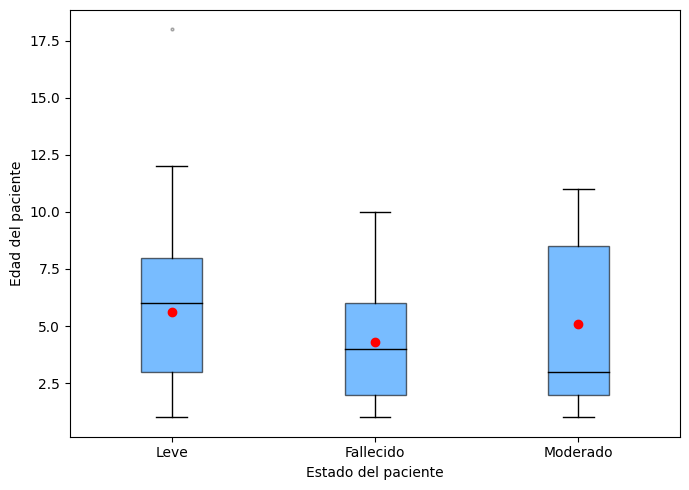

In [52]:
#df_bebes=df_limpio[(df_limpio["Unidad de medida de edad"]==1)]

fig, ax = plt.subplots(figsize=(7, 5))

estados = df_bebe_meses["Estado"].unique()

grupos = [
    df_bebe_meses[df_bebe_meses["Estado"] == g]["Edad"].dropna()
    for g in estados
]

bp = ax.boxplot(
    grupos,
    labels=estados,
    patch_artist=True,
    boxprops=dict(facecolor='#1E90FF', alpha=0.6, color='black'),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor='gray', marker='o', markersize=2, alpha=0.3)
)

for i, g in enumerate(grupos, start=1):
    ax.plot(i, g.mean(), marker='o', color='red', markersize=6, zorder=5)

ax.set_xlabel('Estado del paciente')
ax.set_ylabel('Edad del paciente')

plt.tight_layout()
plt.show()

In [53]:
tabla_grupos = df_bebe_meses.groupby('Estado').apply(resumen).reset_index()

col_total = df_bebe_meses['Edad'].dropna()
tabla_total = pd.DataFrame([{
    'Estado': 'TOTAL',
    'n':          len(df_bebe_meses['Edad']),
    'media':      col_total.mean(),
    'ds':         col_total.std(),
    'mediana':    col_total.median(),
    'minimo':     col_total.min(),
    'maximo':     col_total.max(),
    'Q1':         col_total.quantile(0.25),
    'Q3':         col_total.quantile(0.75),
    'IQR':        col_total.quantile(0.75) - col_total.quantile(0.25)
}])
pd.concat([tabla_grupos, tabla_total], ignore_index=True).round(2)

C:\Users\User\AppData\Local\Temp\ipykernel_13668\2964669324.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_grupos = df_bebe_meses.groupby('Estado').apply(resumen).reset_index()


,Estado,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,Fallecido,20.0,4.30,2.68,4.0,1.0,10.0,2.0,6.0,4.0
1,Leve,1886.0,5.60,3.15,6.0,1.0,18.0,3.0,8.0,5.0
2,Moderado,11.0,5.09,4.06,3.0,1.0,11.0,2.0,8.5,6.5
3,TOTAL,1917.0,5.58,3.15,6.0,1.0,18.0,3.0,8.0,5.0


**Descripción:**   

- Diagrama de cajas y bigotes: el gráfico muestra la distribución de la edad de bebés entre 1 y 18 meses según el estado del paciente. El grupo leve presenta una mediana cercana a 6 meses y una dispersión moderada, además de un valor atípico alrededor de los 18 meses. El grupo fallecido tiene una mediana de aproximadamente 4 meses y menor variabilidad, mientras que el grupo moderado muestra una mediana menor (3 meses) y mayor dispersión. En general, las distribuciones se superponen, lo que indica que las diferencias de edad entre los grupos no son muy marcadas.  

- Tabla de estadísticos: se analizaron 1917 bebés, con una mediana de edad de 6 meses. La mayoría de los casos corresponde al estado leve (1886), con una mediana de 6 meses, lo que indica que la mitad de los pacientes en este grupo tiene menos de esa edad. En los estados fallecido (20) y moderado (11) las medianas son de 4 meses y 3 meses, respectivamente; sin embargo, debido al tamaño reducido de estos grupos, estos resultados deben interpretarse con cautela. En general, las medianas de edad entre los estados clínicos son relativamente cercanas, lo que sugiere que en este rango etario no se observan grandes diferencias en la edad entre los grupos.   

### Gráfico de cajas y bigotes multiple y comparación de medidas de tendencia central para menores de un mes de vida 

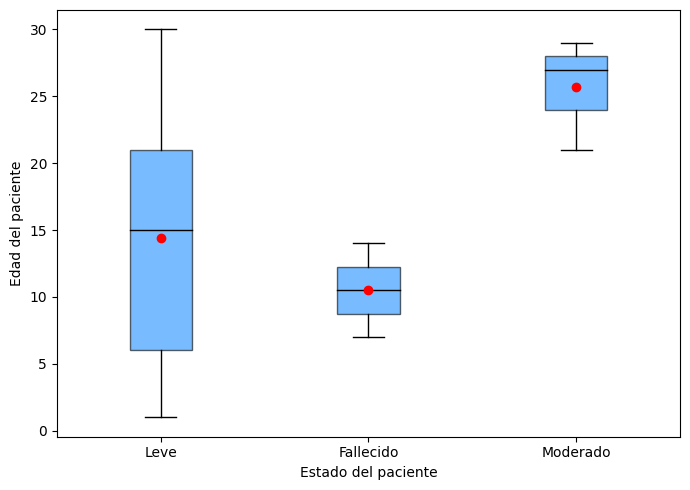

In [54]:
fig, ax = plt.subplots(figsize=(7, 5))

estados = df_bebe_dias["Estado"].unique()

grupos = [
    df_bebe_dias[df_bebe_dias["Estado"] == g]["Edad"].dropna()
    for g in estados
]

bp = ax.boxplot(
    grupos,
    labels=estados,
    patch_artist=True,
    boxprops=dict(facecolor='#1E90FF', alpha=0.6, color='black'),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor='gray', marker='o', markersize=2, alpha=0.3)
)

for i, g in enumerate(grupos, start=1):
    ax.plot(i, g.mean(), marker='o', color='red', markersize=6, zorder=5)

ax.set_xlabel('Estado del paciente')
ax.set_ylabel('Edad del paciente')

plt.tight_layout()
plt.show()

In [55]:
tabla_grupos = df_bebe_dias.groupby('Estado').apply(resumen).reset_index()

col_total = df_bebe_dias['Edad'].dropna()
tabla_total = pd.DataFrame([{
    'Estado': 'TOTAL',
    'n':          len(df_bebe_dias['Edad']),
    'media':      col_total.mean(),
    'ds':         col_total.std(),
    'mediana':    col_total.median(),
    'minimo':     col_total.min(),
    'maximo':     col_total.max(),
    'Q1':         col_total.quantile(0.25),
    'Q3':         col_total.quantile(0.75),
    'IQR':        col_total.quantile(0.75) - col_total.quantile(0.25)
}])
pd.concat([tabla_grupos, tabla_total], ignore_index=True).round(2)

C:\Users\User\AppData\Local\Temp\ipykernel_13668\4150139125.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_grupos = df_bebe_dias.groupby('Estado').apply(resumen).reset_index()


,Estado,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,Fallecido,2.0,10.50,4.95,10.5,7.0,14.0,8.75,12.25,3.5
1,Leve,190.0,14.37,8.80,15.0,1.0,30.0,6.00,21.00,15.0
2,Moderado,3.0,25.67,4.16,27.0,21.0,29.0,24.00,28.00,4.0
3,TOTAL,195.0,14.50,8.82,15.0,1.0,30.0,6.00,21.00,15.0


**Descripción:**  

- Diagrama de cajas y bigotes: el gráfico muestra la distribución de la edad (en días) de bebés menores de 1 mes según el estado del paciente. El grupo leve presenta la mayor cantidad de casos y una amplia dispersión, con una mediana cercana a 15 días y edades entre 1 y 30 días. El grupo moderado muestra edades más altas, con una mediana aproximada de 27 días y menor variabilidad. En el caso del estado fallecido, solo se observa un registro de 14 días, por lo que no es posible analizar su distribución.  

- Tabla de estadísticos: en los 195 bebés menores de 1 mes, la mediana de edad es de 15 días, lo que indica que la mitad de los pacientes tiene menos de 15 días y la otra mitad más. En el estado leve, que concentra la mayoría de los casos (190), la mediana también es 15 días, con el 50 % de las edades entre 6 y 21 días. En el estado moderado, la mediana es 27 días, lo que sugiere que los casos moderados se concentran en bebés de mayor edad dentro del primer mes. Por otro lado, el estado fallecido presenta un solo caso con 14 días, por lo que no es posible realizar un análisis representativo para este grupo.  

## Análisis de la variable de respuesta frente a las variables categóricas  

### Variable "fecha reporte web"  

La variable fecha de reporte web se excluyó del análisis bivariado con la variable de respuesta estado del paciente (leve, moderado, grave o fallecido), ya que corresponde a una variable temporal asociada al registro administrativo de los casos dentro del sistema de vigilancia epidemiológica. Esta variable indica el momento en que la información fue cargada en la plataforma, pero no representa una característica clínica, demográfica o epidemiológica del paciente que pueda influir directamente en su estado de salud, por lo que no aporta información relevante para el análisis de asociación.   

### Variable "Fecha de notificación"   

De manera similar, la fecha de notificación también fue excluida del análisis bivariado con la variable estado del paciente, debido a que se trata de una variable temporal relacionada con el proceso de reporte de los casos a las autoridades de salud. Esta fecha depende del flujo de notificación del sistema de vigilancia y no refleja características propias del paciente ni factores asociados a la gravedad de la enfermedad, por lo que su inclusión no resulta pertinente para evaluar la relación con la variable de respuesta.   

### Variable Código DIVIPOLA municipio  

La variable Código DIVIPOLA municipio se excluyó del análisis bivariado con la variable de respuesta estado del paciente (leve, moderado, grave o fallecido) debido a que corresponde a un código identificador administrativo utilizado para clasificar los municipios en Colombia. Esta variable funciona únicamente como un identificador geográfico y no representa una característica demográfica, clínica o epidemiológica del paciente. Por esta razón, su inclusión no aporta información relevante para evaluar la asociación con el estado del paciente, siendo más apropiado utilizar variables geográficas categóricas interpretables, como el nombre del municipio o departamento, en caso de requerir análisis territoriales.    

### Variable Unidad de medida de edad   

Esta variable ya fue analizada junto a la variable Edad, entonces no es necesario un analisis exhaustivo porque no aporta nada frente a la variable de respuesta Estado.    

### Variable Sexo 

In [56]:
# Tabla de distribución de sexo según Estado del paciente
from IPython.display import display, HTML

tabla_sexo = (
    df_limpio.groupby("Estado")["Sexo"]
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Sexo': 'categoria'})
    .assign(variable='Sexo')
)
tabla_sexo['porcentaje'] = tabla_sexo.groupby('Estado')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_sexo = tabla_sexo[['Estado', 'variable', 'categoria', 'n', 'porcentaje']].sort_values('n', ascending=False)

display(HTML(
    '<div style="height:400px; overflow-y:auto; border:1px solid #ccc;">'
    + tabla_sexo.to_html(index=False) +
    '</div>'
))

Estado,variable,categoria,n,porcentaje
Leve,Sexo,F,217452,53.51
Leve,Sexo,M,188889,46.49
Fallecido,Sexo,M,7188,56.68
Fallecido,Sexo,F,5494,43.32
Moderado,Sexo,F,22,62.86
Moderado,Sexo,M,13,37.14
Grave,Sexo,F,3,100.00


La distribución del Sexo según el estado clínico de los pacientes muestra diferencias relevantes en los patrones de severidad en el Atlántico. Entre los casos donde el paciente Falleció, el 56.68% corresponden a hombres (7,188 casos) y el 43.32% a mujeres (5,494 casos). En contraste, en el grupo de pacientes con estado Leve, la tendencia se invierte, observándose una mayoría femenina del 53.51% (217,452 casos) frente a un 46.49% de hombres.  
Esta diferencia sugiere que, si bien las mujeres registran un mayor volumen de contagios leves en el departamento, los hombres son significativamente más propensos a derivar en desenlaces fatales. Por otro lado, aunque las categorías Moderado y Grave presentan un tamaño muestral mucho menor, mantienen el predominio femenino en frecuencia (62.86% y 100% respectivamente). En general, los datos confirman que el sexo masculino presenta una mayor vulnerabilidad ante la mortalidad por COVID-19, mientras que el sexo femenino concentra la mayoría de los cuadros clínicos no letales.  

**Gráfico de barras multiple**  

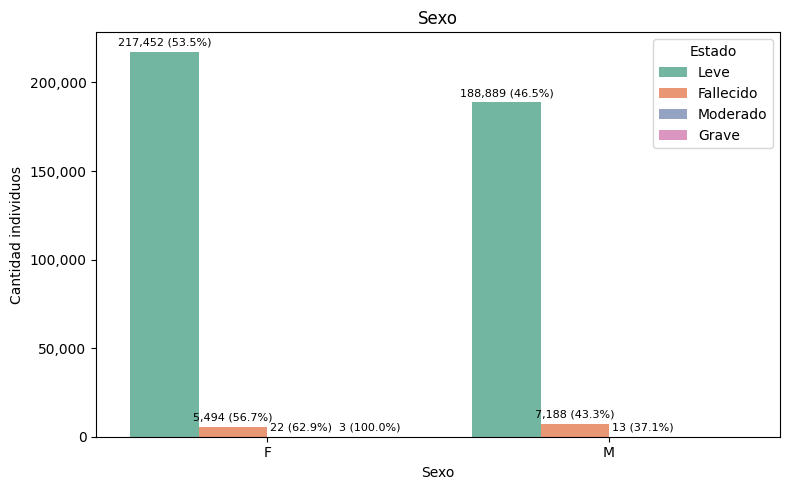

In [57]:
df_plot = tabla_sexo.copy()

df_plot['label'] = df_plot.apply(
    lambda x: f"{int(x['n']):,} ({x['porcentaje']:.1f}%)",
    axis=1
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(x='categoria',y='n',hue='Estado',data=df_plot,palette='Set2',dodge=True
)

for container in ax.containers:
    labels = [f"{int(v):,} ({p:.1f}%)"
              for v, p in zip(
                  container.datavalues,
                  df_plot.loc[
                      df_plot['Estado'] ==
                      container.get_label(),
                      'porcentaje'
                  ]
              )]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad individuos')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
plt.tight_layout()
plt.show()

La distribución por sexo según el estado clínico revela patrones diferenciados: en los casos leves predominan las mujeres con 217,452 casos (53.5%) frente a 188,889 hombres (46.5%); sin embargo, en los fallecidos la tendencia se invierte, siendo los hombres quienes representan la mayoría con 7,188 casos (56.7%) frente a 5,494 mujeres (43.3%), lo que confirma la mayor vulnerabilidad masculina ante la mortalidad por COVID-19. En cuanto a los casos moderados, las mujeres lideran con 22 casos (62.9%) frente a 13 hombres (37.1%), y en los graves se registran exclusivamente 3 mujeres (100%), aunque estas últimas categorías tienen un tamaño muestral muy reducido que limita las conclusiones.    

**Prueba de independencia**    

In [58]:
tabla_contingencia = pd.crosstab(df_limpio['Sexo'], df_limpio['Estado'])

chi2, p_valor, dof, esperados = chi2_contingency(tabla_contingencia)

print(f"Estadístico Chi-cuadrado: {chi2}")
print(f"P-valor: {p_valor}")
print(f"Grados de libertad: {dof}")

Estadístico Chi-cuadrado: 517.1996702478843
P-valor: 8.935627326221832e-112
Grados de libertad: 3


Existe una relación estadísticamente significativa entre el sexo y el estado clínico de los pacientes en el Atlántico. Con un P-valor de prácticamente cero y un estadístico de 517.19, se confirma que la gravedad de la enfermedad no se distribuye de forma aleatoria entre hombres y mujeres, sugiriendo que el género es un factor determinante en la evolución clínica de los casos en el departamento.    

### Variable Tipo de contagio   

In [59]:
tabla_contagio = (
    df_limpio.groupby("Estado")["Tipo de contagio"]
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Tipo de contagio': 'categoria'})
    .assign(variable='Tipo de contagio')
)
tabla_contagio['porcentaje'] = tabla_contagio.groupby('Estado')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_contagio = tabla_contagio[['Estado', 'variable', 'categoria', 'n', 'porcentaje']].sort_values('n', ascending=False)

display(HTML(
    '<div style="height:400px; overflow-y:auto; border:1px solid #ccc;">'
    + tabla_contagio.to_html(index=False) +
    '</div>'
))

Estado,variable,categoria,n,porcentaje
Leve,Tipo de contagio,Comunitaria,278324,68.50
Leve,Tipo de contagio,Relacionado,127945,31.49
Fallecido,Tipo de contagio,Comunitaria,9881,77.91
Fallecido,Tipo de contagio,Relacionado,2799,22.07
Leve,Tipo de contagio,Importado,72,0.02
Moderado,Tipo de contagio,Comunitaria,35,100.00
Grave,Tipo de contagio,Comunitaria,3,100.00
Fallecido,Tipo de contagio,Importado,2,0.02


La distribución del Tipo de contagio según el estado del paciente muestra diferencias relevantes en los patrones de severidad. Entre los casos donde el paciente Falleció, el 77.91% corresponden a contagios de origen Comunitario (9,881 casos) y el 22.07% a casos Relacionados (2,799 casos). En contraste, en el grupo de pacientes con estado Leve, la proporción de contagios comunitarios es menor, situándose en un 68.50%, mientras que los casos relacionados ascienden al 31.49% y los importados representan apenas un 0.02%.   
Esta diferencia sugiere que los contagios de origen comunitario son significativamente más propensos a derivar en desenlaces fatales; de hecho, en las categorías de estado Moderado y Grave, este tipo de contagio abarca el 100% de los registros. En general, el contagio comunitario no solo es el más frecuente en el departamento, sino que presenta una mayor letalidad relativa en comparación con los casos de contacto relacionado.   

**Gráfico de barras multiple**  

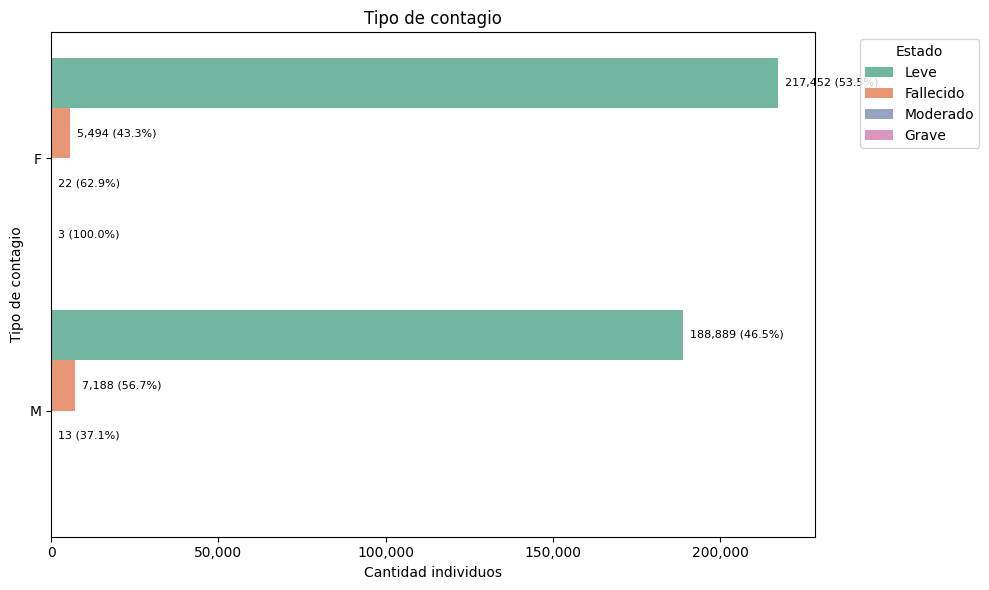

In [60]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    y='categoria', 
    x='n',        
    hue='Estado', 
    data=df_plot, 
    palette='Set2', 
    dodge=True
)

for container in ax.containers:
    labels = [f"{int(v):,} ({df_plot.loc[(df_plot['Estado'] == container.get_label()) & (df_plot['n'] == v), 'porcentaje'].values[0]:.1f}%)" 
              if v > 0 else "" for v in container.datavalues]
    
    ax.bar_label(container, labels=labels, padding=5, fontsize=8)

plt.title('Tipo de contagio')
plt.ylabel('Tipo de contagio')
plt.xlabel('Cantidad individuos')

plt.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

La distribución por Tipo de contagio según el estado clínico revela patrones diferenciados en el Atlántico, en los casos leves predomina el contagio comunitario con 278,324 casos (68.5%) frente a 127,945 casos relacionados (31.5%); sin embargo, en los fallecidos la brecha se amplía significativamente, siendo el contagio comunitario el responsable de la gran mayoría con 9,881 casos (77.9%) frente a 2,799 casos relacionados (22.1%), lo que sugiere una mayor letalidad asociada a la transmisión local. En cuanto a los casos moderados y graves, estos se registran exclusivamente bajo la categoría de contagio comunitario (100% con 35 y 3 casos respectivamente), mientras que los casos importados presentan una incidencia marginal cercana al 0.0% en todas las categorías de gravedad, confirmando que el motor de la crisis sanitaria fue la propagación interna en el departamento.  

**Prueba de independencia**  

In [61]:
tabla_contingencia = pd.crosstab(df_limpio['Tipo de contagio'], df_limpio['Estado'])

chi2, p_valor, dof, esperados = chi2_contingency(tabla_contingencia)

print(f"Estadístico Chi-cuadrado: {chi2}")
print(f"P-valor: {p_valor}")
print(f"Grados de libertad: {dof}")

Estadístico Chi-cuadrado: 525.3964484312679
P-valor: 2.8366220702805916e-110
Grados de libertad: 6


Existe una relación estadísticamente significativa entre el tipo de contagio y el estado clínico de los pacientes en el Atlántico. Con un P-valor de prácticamente cero y un estadístico de 525.39, se confirma que la gravedad de la enfermedad no se distribuye de forma aleatoria según el origen de la infección, sugiriendo que el tipo de contagio (especialmente el comunitario) es un factor determinante en la evolución clínica y la mortalidad de los casos en el departamento.  

### Variable Ubicación del caso  

In [62]:
tabla_ubicacion = (
    df_limpio.groupby("Estado")["Ubicación del caso"]
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Ubicación del caso': 'categoria'})
    .assign(variable='Ubicación del caso')
)
tabla_ubicacion['porcentaje'] = tabla_ubicacion.groupby('Estado')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_ubicacion = tabla_ubicacion[['Estado', 'variable', 'categoria', 'n', 'porcentaje']].sort_values('n', ascending=False)

display(HTML(
    '<div style="height:400px; overflow-y:auto; border:1px solid #ccc;">'
    + tabla_ubicacion.to_html(index=False) +
    '</div>'
))

Estado,variable,categoria,n,porcentaje
Leve,Ubicación del caso,Casa,406341,100.0
Fallecido,Ubicación del caso,Fallecido,12682,100.0
Moderado,Ubicación del caso,Hospital,35,100.0
Grave,Ubicación del caso,Hospital uci,3,100.0


La distribución de la Ubicación del caso según el estado clínico del paciente revela una segmentación absoluta en los patrones de atención en el Atlántico. Entre los casos donde el paciente Falleció, el 100% de los registros corresponden a la categoría de ubicación Fallecido (12,682 casos), mientras que en el grupo de pacientes con estado Leve, la totalidad de los individuos (100%) fueron atendidos en Casa (406,341 casos). En contraste, los niveles de mayor complejidad clínica muestran que los pacientes en estado Moderado se encuentran exclusivamente en Hospital (35 casos) y los pacientes en estado Grave fueron dirigidos en su totalidad a Hospital UCI (3 casos). Esta correspondencia perfecta indica que la ubicación del paciente en el dataset funciona como un reflejo directo de la severidad clínica, confirmando que el sistema de salud del departamento clasificó y distribuyó la carga asistencial de manera estrictamente vinculada a la gravedad del cuadro de cada individuo. Por tanto, no es necesario seguir haciendo el analisis de estas dos variables porque no da mucha información adicional.    

### Variable Recuperado

In [63]:
tabla_recuperado = (
    df_limpio.groupby("Estado")["Recuperado"]
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Recuperado': 'categoria'})
    .assign(variable='Recuperado')
)
tabla_recuperado['porcentaje'] = tabla_recuperado.groupby('Estado')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_recuperado = tabla_recuperado[['Estado', 'variable', 'categoria', 'n', 'porcentaje']].sort_values('n', ascending=False)

display(HTML(
    '<div style="height:400px; overflow-y:auto; border:1px solid #ccc;">'
    + tabla_recuperado.to_html(index=False) +
    '</div>'
))

Estado,variable,categoria,n,porcentaje
Leve,Recuperado,Recuperado,406317,99.99
Fallecido,Recuperado,Fallecido,12682,100.00
Moderado,Recuperado,Activo,35,100.00
Leve,Recuperado,Activo,24,0.01
Grave,Recuperado,Activo,3,100.00


La distribución del estado Recuperado según la condición clínica del paciente muestra una correlación directa entre el proceso de alta y la severidad inicial en el Atlántico. Entre los casos registrados como Fallecidos, el 100% (12,682 casos) se clasifican como Fallecido, mientras que en el grupo de pacientes con estado Leve, la inmensa mayoría de 99.99% (406,317 casos) logró la recuperación, quedando solo un residual de 24 casos (0.01%) aún en estado Activo. Por su parte, en los niveles de mayor complejidad, se observa que el 100% de los casos Moderados (35 registros) y Graves (3 registros) permanecen como casos Activos. Esta segmentación confirma que la recuperación fue el desenlace casi universal para los cuadros leves, mientras que la gravedad clínica y la mortalidad definieron de manera estricta el estatus final del paciente en los registros del departamento. Por tanto, no es necesario seguir haciendo el analisis de estas dos variables porque no da mucha información adicional.   

### Variable Fecha de inicio de síntomas   

La variable fecha de inicio de síntomas se excluyó del análisis bivariado con la variable de respuesta estado del paciente, ya que, al ser una variable de naturaleza temporal, su función principal es marcar el inicio cronológico de la enfermedad. Si bien es fundamental para construir curvas epidemiológicas, no constituye una característica biológica o demográfica del individuo que determine por sí misma la gravedad del cuadro. Al tratarse de una serie de puntos en el tiempo y no de un factor de riesgo cualitativo, su inclusión en pruebas de asociación no aportaría información relevante para identificar los determinantes clínicos que influyen en el desenlace del paciente.    

### Variable Fecha de diagnóstico  

La variable fecha de diagnóstico se excluyó del análisis bivariado con el estado del paciente, ya que es un dato cronológico que indica únicamente el momento en que se confirmó la presencia del virus mediante una prueba de laboratorio. Al ser una variable de registro temporal, no constituye un factor de riesgo biológico ni una característica clínica que determine la gravedad del cuadro, por lo que su inclusión no aporta información relevante para identificar las causas de la mortalidad o severidad en el departamento.

### Variable Fecha de recuperación  

La variable fecha de recuperación se excluyó del análisis bivariado con la variable de respuesta estado del paciente, debido a que representa un evento posterior al desenlace clínico y está condicionada administrativamente al estado previo del individuo. Al tratarse de una marca de tiempo que solo existe para quienes superaron la enfermedad, su uso en pruebas de asociación resultaría redundante y no permitiría identificar atributos demográficos o epidemiológicos que influyan originalmente en la evolución hacia un estado leve o crítico.  

### Variable Tipo de recuperación  

In [64]:
tabla_tiporec = (
    df_limpio.groupby("Estado")["Tipo de recuperación"]
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Tipo de recuperación': 'categoria'})
    .assign(variable='Tipo de recuperación')
)
tabla_tiporec['porcentaje'] = tabla_tiporec.groupby('Estado')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_tiporec = tabla_tiporec[['Estado', 'variable', 'categoria', 'n', 'porcentaje']].sort_values('n', ascending=False)

display(HTML(
    '<div style="height:400px; overflow-y:auto; border:1px solid #ccc;">'
    + tabla_tiporec.to_html(index=False) +
    '</div>'
))

Estado,variable,categoria,n,porcentaje
Leve,Tipo de recuperación,Tiempo,308672,75.96
Leve,Tipo de recuperación,Pcr,97669,24.04
Fallecido,Tipo de recuperación,No aplica,12682,100.00
Moderado,Tipo de recuperación,Tiempo,35,100.00
Grave,Tipo de recuperación,Tiempo,3,100.00


La distribución del Tipo de recuperación según el estado clínico en el Atlántico refleja una segmentación puramente administrativa y procedimental. Mientras que en los casos fallecidos la categoría es unánimemente No aplica (100%), en los pacientes leves predomina la recuperación por Tiempo con un 75.96% (308,672 casos) sobre el uso de pruebas Pcr (24.04%). Por su parte, los estados moderado y grave se asocian exclusivamente a la recuperación por tiempo (100%), confirmando que esta variable depende directamente de los protocolos de alta y el desenlace clínico del paciente. Por tanto, su análisis no aporta información epidemiológica adicional relevante para identificar factores de riesgo externos.   

### Variable Pertenencia étnica 

In [65]:
tabla_etnia = (
    df_limpio.groupby("Estado")["Pertenencia étnica"]
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Pertenencia étnica': 'categoria'})
    .assign(variable='Pertenencia étnica')
)
tabla_etnia['porcentaje'] = tabla_etnia.groupby('Estado')['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_etnia = tabla_etnia[['Estado', 'variable', 'categoria', 'n', 'porcentaje']].sort_values('n', ascending=False)

display(HTML(
    '<div style="height:400px; overflow-y:auto; border:1px solid #ccc;">'
    + tabla_etnia.to_html(index=False) +
    '</div>'
))

Estado,variable,categoria,n,porcentaje
Leve,Pertenencia étnica,6.0,383765,94.44
Leve,Pertenencia étnica,5.0,16537,4.07
Fallecido,Pertenencia étnica,6.0,11978,94.45
Leve,Pertenencia étnica,1.0,6032,1.48
Fallecido,Pertenencia étnica,5.0,472,3.72
Fallecido,Pertenencia étnica,1.0,232,1.83
Moderado,Pertenencia étnica,6.0,35,100.00
Leve,Pertenencia étnica,2.0,6,0.00
Grave,Pertenencia étnica,6.0,3,100.00
Leve,Pertenencia étnica,3.0,1,0.00


La distribución de la Pertenencia étnica según el estado clínico en el Atlántico muestra una homogeneidad marcada, con la categoría Otro (6) como el grupo predominante en todos los desenlaces. Tanto en los casos leves como en los fallecidos, esta categoría representa aproximadamente el 94.4% de los registros (383,765 y 11,978 casos respectivamente), seguida por una participación minoritaria de la población Negra (5) y la Indígena (1), que oscilan entre el 1.4% y el 4.0%. Por su parte, en los estados moderado y grave, la categoría Otro abarca el 100% de los casos reportados. Esta similitud proporcional entre los distintos estados clínicos sugiere que la pertenencia étnica no fue un factor determinante en la severidad o mortalidad de los contagios, reflejando más bien la composición demográfica general o los patrones de registro administrativo en el departamento.   

# Modelo básico de Regresión Logistica  

Se verificará el score del modelo de represión logística para predecir la variable de respuesta de Estado del paciente dependiendo de las variables restantes, cabe resaltar que al tener pocas observaciones con estado moderado y grave, el modelo será binario y buscará predecir el si la persona fallece o tendrá síntomas leves, además se dividirá el dataset con un 80% para train y 20% test.    
Dado que es un modelo sencillo y en la variable de respuesta las categorías están desbalanceadas, se reducirá el número de observaciones de la categoría "leve" para que tenga la misma frecuencia que las de estado "fallecido", en este caso se quieren igualar a 12682.  


In [66]:
#Aquí se hace el Undersampling
df_modelo = df_limpio[[
    "Edad",
    "Sexo",
    "Tipo de contagio",
    "Pertenencia étnica",
    "Estado"
]].copy()
df_modelo = df_modelo[df_modelo["Estado"].isin(["Fallecido", "Leve"])]
#se separan las clase
df_fallecido = df_modelo[df_modelo["Estado"] == "Fallecido"]
df_leve = df_modelo[df_modelo["Estado"] == "Leve"]

#Tomar una muestra aleatoria de Leve igual al tamaño de Fallecido, en nuestro caso son 12682 la frecuencia a igualar
df_leve_resampled = df_leve.sample(n=len(df_fallecido), random_state=42)

#Concatenar de nuevo y mezclar el orden
df_balanceado = pd.concat([df_fallecido, df_leve_resampled]).sample(frac=1, random_state=42)

# Verificar los nuevos resultados
print(df_balanceado["Estado"].value_counts())

Estado
Fallecido    12682
Leve         12682
Name: count, dtype: int64


In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df_balanceado["Estado"] = df_balanceado["Estado"].astype("category").cat.codes

df_balanceado = pd.get_dummies(df_balanceado, drop_first=True)

#Separamos variables
X = df_balanceado.drop("Estado", axis=1)
y = df_balanceado["Estado"]

#Division del data set, en nuestro caso tomamos 80% train y 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # importante en binaria
)

modelo = LogisticRegression(max_iter=1000, class_weight="balanced")
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

# Resultados
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nInforme detallado:")
print(classification_report(y_test, y_pred))

Exactitud Global (Accuracy): 0.8011

Matriz de confusión:
[[2095  442]
 [ 567 1969]]

Informe detallado:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      2537
           1       0.82      0.78      0.80      2536

    accuracy                           0.80      5073
   macro avg       0.80      0.80      0.80      5073
weighted avg       0.80      0.80      0.80      5073



El modelo presenta un desempeño sólido y equilibrado tras el balanceo, logrando una exactitud global del 80.1%. Lo más destacable es la simetría en las métricas de ambas clases (0 y 1), con un f1-score casi idéntico (0.81 y 0.80 respectivamente). Esto indica que el submuestreo fue efectivo, permitiendo que el algoritmo aprenda a identificar los casos de la clase minoritaria (Fallecidos) con una precisión del 82% y una sensibilidad (recall) del 78%, evitando el sesgo hacia la clase que antes era mayoritaria.  

Sin embargo, la matriz de confusión revela que todavía existe un margen de error importante en los falsos negativos y falsos positivos (567 y 442 casos). En un contexto médico o de salud pública, el recall de la clase 1 (0.78) es la métrica crítica, ya que implica que el modelo no logra detectar aproximadamente al 22% de las personas fallecidas, clasificándolas erróneamente como casos leves. En pocas palabras, al estar en un contexto médico es necesario subir estás metricas porque es posible que 567 personas fallezcan si no se detecta a tiempo.  

# Conclusiones  

El análisis epidemiológico en el Atlántico confirma que el sexo y el tipo de contagio son determinantes críticos en la severidad de la enfermedad. Mientras las mujeres representan la mayoría de los casos leves (53.5%), la mortalidad muestra una clara inclinación hacia los hombres, quienes concentran el 56.7% de los fallecimientos. Esta vulnerabilidad masculina se complementa con el impacto del contagio comunitario, el cual no solo fue el motor principal de la pandemia, sino que incrementó su peso proporcional del 68.5% en estados leves al 77.9% en los fatales, abarcando además la totalidad de los casos moderados y graves registrados.  

Por otro lado, la gestión hospitalaria y los protocolos de salida demostraron una segmentación administrativa absoluta y coherente con la gravedad del paciente. El sistema de salud logró una correspondencia del 100% entre el estado clínico y la ubicación (leves en casa y críticos en UCI), utilizando la recuperación por tiempo como el principal mecanismo de alta para el 75.9% de los casos. Finalmente, la pertenencia étnica no evidenció disparidades significativas en la evolución clínica, manteniendo una distribución homogénea del 94.4% en la categoría "Otro" para todos los niveles de severidad, lo que sugiere que el impacto del virus se distribuyó de manera uniforme bajo los patrones de registro demográfico actuales del departamento.  